In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install plotly

# **Project Name** - Exploratory Data Analysis on Amazon Prime TV Shows and Movies

##### **Project Type**    - EDA
##### **Contribution**    - Individual

 **Project Summary**: Exploratory Data Analysis on Amazon Prime TV Shows and Movies



In this project, I performed **Exploratory Data Analysis (EDA)** on the Amazon Prime Movies and TV Shows dataset to understand content trends, patterns, and relationships between different variables.

**Datasets Used**

**Titles Dataset:** 9,871 records covering title, type, genre, runtime, release year, and ratings.

**Credits Dataset:** 124,000+ entries detailing actors, directors, and their roles.

Using **Pandas** and **NumPy**, I cleaned and prepared the dataset by handling missing values, correcting data types, managing duplicates, and transforming columns where necessary. This ensured the dataset was structured and ready for analysis.

With the help of **Matplotlib** , **Seaborn** and **Plotly** I created various visualizations to explore:

- Distribution of movies and TV shows

- Release year trends

- Runtime distribution and detection of short-duration outliers

- IMDb score and vote patterns

- Content production by country

Correlation between numerical features such as IMDb score, votes, runtime, and popularity

I performed both **univariate analysis** (distribution of individual features) and **bivariate analysis** (relationships between two variables), including heatmaps to understand correlation strength between numerical variables.

 **Key Insights Gained**:

**1. Content Portfolio is Movie-Dominant**

The platform’s catalog is heavily skewed toward movies compared to TV shows. While TV shows tend to span multiple seasons, they represent a smaller portion of total titles. This indicates a content strategy focused primarily on standalone film distribution.

**2. Strong Content Expansion After 2015**

There is a noticeable surge in content additions in recent years, particularly post-2015. This suggests an aggressive acquisition and production strategy aligned with the rapid growth of streaming competition and digital consumption trends.

**3. Standardized Runtime Pattern with Short-Form Presence**

Most movies fall within the 80–120 minute range, reflecting industry standards for feature-length films. However, the dataset contains a significant number of titles under 15 minutes, likely representing short films, special episodes, or non-standard entries. The runtime distribution is slightly right-skewed, indicating a small number of very long titles.

**4. Weak Correlation Between IMDb Votes and Ratings**

The correlation between IMDb votes and IMDb score is weakly positive. While higher vote counts improve rating reliability, they do not necessarily lead to higher ratings. This highlights that popularity and perceived quality are distinct metrics.

**5. Popularity Does Not Guarantee Quality**

TMDB popularity shows limited correlation with IMDb score. Highly marketed or trending content does not always receive strong audience ratings, indicating that visibility and user satisfaction are influenced by different factors.

**6. Country-Wise Production Concentration**

Content production is concentrated in a few dominant countries, with the United States contributing the largest share. Emerging markets such as India show increasing representation, suggesting opportunities for regional expansion strategies.

**7. Rating Reliability Improves with Vote Thresholds**

Titles with very low vote counts display higher rating variability. Applying a minimum vote threshold enhances the reliability of rating-based analysis and prevents skewed interpretations from niche or recently released titles.

**8. Data Quality Observations**

The dataset contains missing values in attributes such as age certification and seasons. Duplicate records and runtime anomalies were identified and addressed, improving the accuracy and credibility of analytical findings

This project strengthened my understanding of:

- Data cleaning techniques

- Feature distribution analysis

- Correlation analysis

- Visualization best practices

- Interpreting real-world entertainment data

Overall, this EDA helped uncover meaningful insights about Amazon Prime content and improved my practical skills in data preprocessing, visualization, and analytical thinking using Python

###**Problem Statement**


This dataset was created to analyze all shows available on Amazon Prime Video, allowing us to extract valuable insights such as:

- Content Diversity: What genres and categories dominate the platform?
- Regional Availability: How does content distribution vary across different regions?
- Trends Over Time: How has Amazon Prime’s content library evolved?
- IMDb Ratings & Popularity: What are the highest-rated or most popular shows on the platform?

By analyzing this dataset, businesses, content creators, and data analysts can uncover key trends that influence subscription growth, user engagement, and content investment strategies in the streaming industry.

#### **Define Your Business Objective?**

This project aims to analyze Amazon Prime Video’s catalog to uncover insights into audience preferences, content diversity, and market trends.

By exploring genres, regions, release patterns, ratings, and cast/crew data, **the goal is to:**

Enhance content strategy by identifying high-performing genres and regions.

Boost audience engagement through data-driven recommendations.

Drive business growth by aligning content investments with viewer demand.

**Importing relevant Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Uploading **Credits** and **Titles** datasets

In [ ]:
#Credits dataset
df=pd.read_csv('/content/credits.csv (1).zip')
#Titles dataset
df1=pd.read_csv('/content/titles.csv.zip')

First view of both the dataset

In [ ]:
#Credit
df

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


In [ ]:
#Title
df1

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN


### **Analysing Titles Dataset**
- Titles dataset has 9871 rows and 15 columns.
- It has 3 duplicated values.


In [ ]:
# Dataset first view
df1

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN


In [ ]:
# checking for duplicate values
df1.duplicated().sum()

np.int64(3)

In [ ]:
# checking if the duplicates are real
df1[df1.duplicated(keep=False)]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
479,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
480,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
718,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
719,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN
720,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN


In [ ]:
# after examining dropping the duplicate values
df1.drop_duplicates(inplace=True)

In [ ]:
df1.duplicated().sum()

np.int64(0)

### **Column Types**


*   **Numerical**- release_year, runtime,seasons,imdb_score, imdb_votes, tmdb_popularity, tmdb_score,
*   **Categorical**- type, age_certification, genres, production_countries,


*   **Mixed**- id, title, description, imdb_id,






### **Univariate** **Analysis** - is the analysis of **a single variable at a time**.
 Its main goal is to understand the Distribution, Central Tendency(mean, median, mode), Spread(variance, SD, range) and Shape(skewness, outlier).

 **Charts used in Univariate Analysis**:-

 **For Numerical Columns:** Histogram, Boxplot, Density Plot, LinePlot

 **For Categorical Columns**:- Bar Chart, Pie Chart, Count Plot


### **Analysis of Numerical Columns**

### Release Year


**Conclusion**
- Release Year column is Negatively Skewed
- Fifty Percent of the content in the dataset was released after 2014
- Natural scarcity of older content
- Outliers in this column are the part of the data.

In [ ]:
#checking the statistics for release year column
df1['release_year'].describe()

,release_year
count,9868.000000
mean,2001.345561
std,25.792295
min,1912.000000
25%,1996.000000
50%,2014.000000
75%,2018.000000
max,2022.000000


<Axes: ylabel='Frequency'>

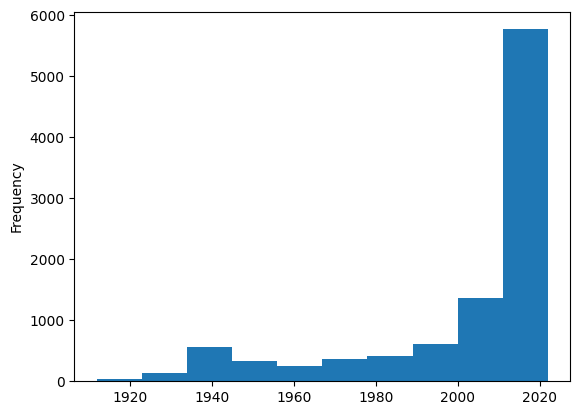

In [ ]:
#plotting a histogram plot to get a look into which year/year dominating
df1['release_year'].plot(kind='hist')

<Axes: ylabel='Density'>

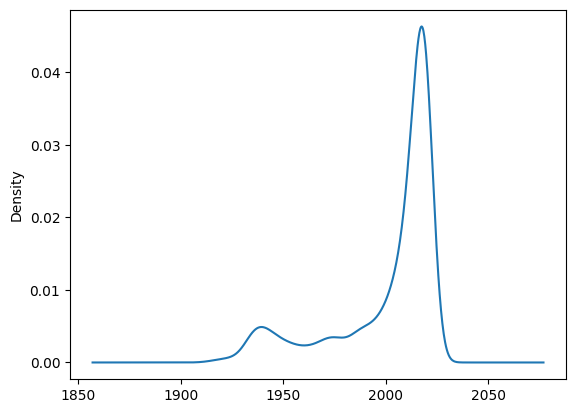

In [ ]:
#plotting the kde plot to understand the shape of distribution
df1['release_year'].plot(kind='kde')

In [ ]:
#checking the skewness of the column
df1['release_year'].skew()

np.float64(-1.5470894225864102)

<Axes: >

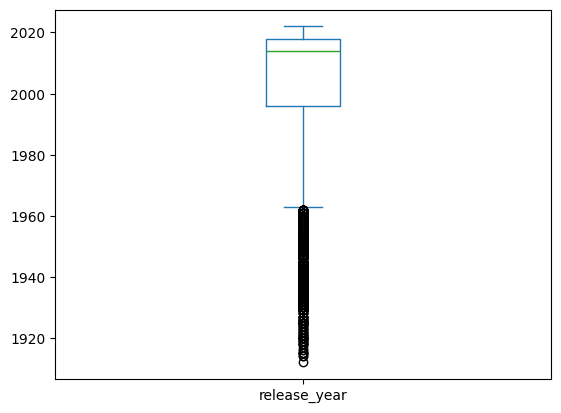

In [ ]:
#plotting the boc plot check outliers
df1['release_year'].plot(kind='box')

In [ ]:
# checking for the outlier if they are the part of the data or not
df1[df1['release_year']<1960].sort_values('release_year')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
506,tm17827,From the Manger to the Cross,MOVIE,The life of Jesus is played out in tableaux sh...,1912,NaN,71,['drama'],['US'],NaN,tt0002199,5.8,588.0,1.235,5.3
228,tm162886,The Patchwork Girl of Oz,MOVIE,"Ojo and Unc Nunkie are out of food, so they de...",1914,NaN,81,"['fantasy', 'comedy', 'family']",['US'],NaN,tt0004457,5.4,477.0,0.980,5.3
180,tm2363,A Florida Enchantment,MOVIE,A young woman discovers a seed that can make w...,1914,NaN,63,"['fantasy', 'comedy']",['US'],NaN,tt0003973,5.8,251.0,1.282,4.4
310,tm5887,"Fanchon, the Cricket",MOVIE,"A young wild girl, Fanchon, lives in a forest ...",1915,NaN,75,['drama'],['US'],NaN,tt0005302,6.5,208.0,0.967,6.5
144,tm154,Alice in Wonderland,MOVIE,Alice goes with her sister to a picnic and the...,1915,NaN,59,"['fantasy', 'family']",['US'],NaN,tt0004873,6.2,510.0,2.531,5.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,tm37210,Riot in Juvenile Prison,MOVIE,When the shootings of two juvenile inmates bri...,1959,NaN,71,"['thriller', 'crime', 'drama']",['US'],NaN,tt0053222,4.9,130.0,1.042,5.0
1706,tm772186,Sahodari,MOVIE,Pazhani has two children — Chandiran and Meena...,1959,NaN,175,[],[],NaN,tt0156989,5.4,6.0,0.600,NaN
1713,tm45041,La Cambiale,MOVIE,The Posalaquaglia cousins are two small scamme...,1959,NaN,105,"['comedy', 'european']",['IT'],NaN,tt0052668,6.7,330.0,3.998,6.7
1649,tm42389,Surrender - Hell!,MOVIE,Director John Barnwell's 1959 WWII drama stars...,1959,NaN,85,"['action', 'war', 'drama']",['US'],NaN,tt0051032,5.8,142.0,0.655,NaN


In [ ]:
# done value count to check if it matches with the total rows of the outliers value
(df1['release_year']<1960).value_counts()

,count
release_year,
False,8695
True,1173


In [ ]:
print("-----count of null values in the column-----")
df1['release_year'].isnull().sum()

-----count of null values in the column-----


np.int64(0)

### Runtime

**Conclusion**
- Most of the data fall in a fairly tight and realistic runtime range
- There is a moderately **right-skewed** distribution in the Runtime data
- Long duration content exist but it does not dominate the dataset
- Extremly high runtime **540 minutes** and **549 minutes** belongs to the dataset because after examing it was found that one is **mini series** and the other is a 9 hour long **movie** based on the 9 hour theme.
- 618 shows has duration less than 30. These short runtimes likely represent
  TV episodes
- There are **32 runtimes** which has duration **less than 5**. After examining it seems that this content mostly belongs to **songs** and **kids**.


In [ ]:
#checking the stats of the column
df1['runtime'].describe()

,runtime
count,9868.000000
mean,85.979124
std,33.515714
min,1.000000
25%,65.000000
50%,89.000000
75%,102.000000
max,549.000000


<Axes: ylabel='Frequency'>

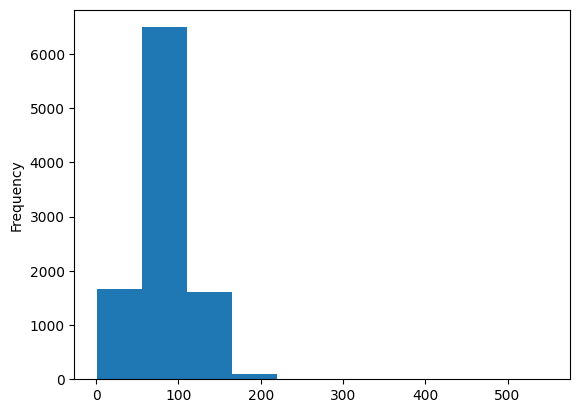

In [ ]:
#plotting the histogram to see frequency distribution
df1['runtime'].plot(kind='hist')

<Axes: ylabel='Density'>

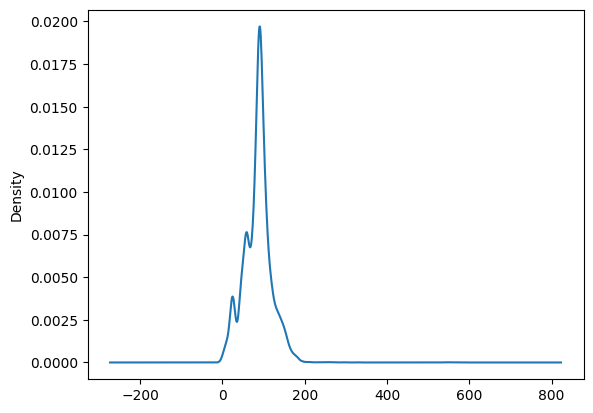

In [ ]:
#plotting the kde plot to understand the distribution
df1['runtime'].plot(kind='kde')


<Axes: >

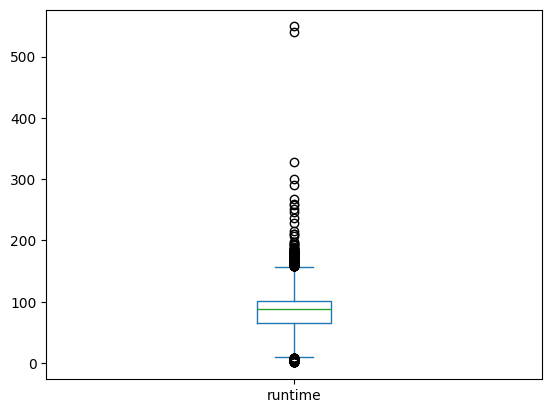

In [ ]:
#plotting the box plot to check outliers
df1['runtime'].plot(kind='box')

In [ ]:
#checking the skewness
df1['runtime'].skew()

np.float64(0.676709447938736)

In [ ]:
# Examining the outlier values
df1[df1['runtime']>200].sort_values('runtime')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1018,tm60579,Exodus,MOVIE,"Based on Leon Uris' novel, this historical epi...",1960,NaN,208,"['action', 'drama', 'history', 'war']","['IL', 'US']",NaN,tt0053804,6.7,9830.0,7.432000,6.7
2710,tm907472,Liz: The Elizabeth Taylor Story,MOVIE,The story of Elizabeth Taylor's rise to stardo...,1995,NaN,210,['drama'],['US'],NaN,tt0113680,6.2,492.0,0.840000,NaN
3132,tm36475,Kabhi Khushi Kabhie Gham,MOVIE,"Rahul, the adoptive son of business magnate Ya...",2001,G,210,"['drama', 'romance']",['IN'],NaN,tt0248126,7.4,48818.0,8.470000,7.9
2492,tm27389,Mohabbatein,MOVIE,"At a prestigious all-male university, three fr...",2000,PG,216,"['drama', 'romance']",['IN'],NaN,tt0213890,7.0,29514.0,12.246000,7.0
148,tm134133,Tarzan the Fearless,MOVIE,"Mary Brooks' father, who has been studying anc...",1933,PG,228,"['action', 'romance', 'family']",['US'],NaN,tt0024645,4.9,711.0,1.795000,3.6
966,tm460775,Jesus of Nazareth,MOVIE,Beginning before the Nativity and extending th...,1977,G,237,"['drama', 'history']","['US', 'IT']",NaN,NaN,NaN,NaN,0.680000,8.7
1004,tm91188,1900,MOVIE,The epic tale of a class struggle in twentieth...,1976,R,246,"['drama', 'european', 'history']","['FR', 'DE', 'IT']",NaN,tt0074084,7.7,25282.0,7.706000,7.9
1995,tm47093,The Murder of Mary Phagan,MOVIE,"The Murder of Mary Phagan, a 1987 two-part TV ...",1988,PG,251,"['drama', 'history', 'crime']",[],NaN,NaN,NaN,NaN,0.000011,NaN
87,tm72394,The Green Hornet,MOVIE,A newspaper publisher and his Korean servant f...,1940,NaN,258,"['crime', 'drama', 'family', 'scifi', 'thriller']",['US'],NaN,tt0031394,6.5,609.0,1.164000,5.9
975,tm87848,The Greatest Story Ever Told,MOVIE,From his birth in Bethlehem to his death and e...,1965,G,260,"['drama', 'documentation', 'history']",['US'],NaN,tt0059245,6.5,10390.0,14.737000,6.4


In [ ]:
# examining the outliers which have short runtime
df1[df1['runtime']<30].sort_values('runtime')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1736,ts95763,Pinkfong! Halloween Songs,SHOW,It's time to celebrate Halloween with ghosts a...,1969,NaN,1,"['music', 'animation', 'family']",[],3.0,tt7818358,3.6,5.0,NaN,NaN
8724,ts278276,Pinkfong! Baby Shark & Christmas Songs,SHOW,Baby Shark and Christmas Songs brings a joyful...,2020,NaN,1,"['music', 'animation', 'family']",[],1.0,tt13766364,NaN,NaN,NaN,NaN
7400,ts104491,Pinkfong! Car Songs,SHOW,Sing along to fun children's songs and learn t...,2017,NaN,1,[],[],1.0,tt9310710,NaN,NaN,NaN,NaN
7120,ts105217,Pinkfong! Dinosaur Songs,SHOW,Shake it! Shake it! Sing and move your body wi...,2017,NaN,1,[],[],2.0,tt9134714,NaN,NaN,NaN,NaN
6464,ts105811,Pinkfong! Baby Shark,SHOW,"Enjoy a collection of ""Baby Shark"" songs. Meet...",2017,TV-Y,1,['family'],['KR'],1.0,tt9103856,1.6,11.0,0.654,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7756,ts86714,King Gary,SHOW,A larger-than-life working-class sitcom that f...,2020,NaN,29,['comedy'],['GB'],2.0,tt9548664,6.7,1168.0,1.159,7.5
9249,ts276796,LOL: Last One Laughing Italy,SHOW,LOL is a comedy show where ten professional co...,2021,NaN,29,"['comedy', 'reality']",['IT'],2.0,tt13620358,7.3,1835.0,4.780,8.1
9229,ts309923,Rafa Nadal Academy,SHOW,NaN,2021,NaN,29,['documentation'],['ES'],1.0,NaN,NaN,NaN,0.722,NaN
9687,ts314872,Akkad Bakkad Rafu Chakkar,SHOW,The “good life” is just one scam away. This th...,2021,NaN,29,['drama'],['IN'],1.0,NaN,NaN,NaN,0.817,NaN


In [ ]:
df1[df1['runtime']<30] ['type'].value_counts()

,count
type,
SHOW,618
MOVIE,63


In [ ]:
# examining the outliers which have very short runtime
df1[df1['runtime']<10].sort_values('runtime')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1736,ts95763,Pinkfong! Halloween Songs,SHOW,It's time to celebrate Halloween with ghosts a...,1969,NaN,1,"['music', 'animation', 'family']",[],3.0,tt7818358,3.6,5.0,NaN,NaN
2401,tm192899,Incognito,MOVIE,Harry Donovan is an art forger who paints fake...,1997,R,1,"['crime', 'thriller', 'romance']",['US'],NaN,tt0119365,6.4,3760.0,5.755,6.1
2924,ts82184,Wallace & Gromit's Cracking Contraptions,SHOW,A look at some of Wallace's labour-saving mech...,2002,TV-G,1,"['comedy', 'animation', 'family', 'european']",['US'],1.0,tt0339881,7.6,2889.0,3.844,9.5
4232,ts84225,Shaun the Sheep Championsheeps,SHOW,Twenty-one minute long sports-themed shorts ma...,2012,NaN,1,"['comedy', 'animation', 'family']",['GB'],1.0,tt2746404,7.7,98.0,1.439,7.8
5512,ts119008,According to Kids,SHOW,NaN,2016,NaN,1,['comedy'],[],4.0,tt7400288,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,ts58029,Lights of the Clione,SHOW,NaN,2017,NaN,9,['drama'],['JP'],1.0,NaN,NaN,NaN,3.176,8.5
6250,ts80458,Barbie Dreamtopia,SHOW,Barbie and her little sister Chelsea travel th...,2017,NaN,9,"['family', 'animation']",['US'],1.0,tt7533146,6.2,48.0,5.012,8.5
5810,ts95801,Alien Monkeys,SHOW,Alien Monkeys is story about two monkeys explo...,2015,NaN,9,['animation'],['KR'],1.0,tt7821974,8.8,23.0,0.600,NaN
8261,ts188533,HobbyKids Adventures,SHOW,"Based on the MEGA-SUCCESSFUL YouTube channel, ...",2019,NaN,9,"['comedy', 'family', 'animation']",[],2.0,tt10139982,2.7,75.0,0.600,4.0


In [ ]:
# examining the outliers which have very short runtime
df1[df1['runtime']<5].sort_values('runtime')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1736,ts95763,Pinkfong! Halloween Songs,SHOW,It's time to celebrate Halloween with ghosts a...,1969,NaN,1,"['music', 'animation', 'family']",[],3.0,tt7818358,3.6,5.0,NaN,NaN
2401,tm192899,Incognito,MOVIE,Harry Donovan is an art forger who paints fake...,1997,R,1,"['crime', 'thriller', 'romance']",['US'],NaN,tt0119365,6.4,3760.0,5.755,6.1
2924,ts82184,Wallace & Gromit's Cracking Contraptions,SHOW,A look at some of Wallace's labour-saving mech...,2002,TV-G,1,"['comedy', 'animation', 'family', 'european']",['US'],1.0,tt0339881,7.6,2889.0,3.844,9.5
4232,ts84225,Shaun the Sheep Championsheeps,SHOW,Twenty-one minute long sports-themed shorts ma...,2012,NaN,1,"['comedy', 'animation', 'family']",['GB'],1.0,tt2746404,7.7,98.0,1.439,7.8
5512,ts119008,According to Kids,SHOW,NaN,2016,NaN,1,['comedy'],[],4.0,tt7400288,NaN,NaN,NaN,NaN
5984,ts95796,Pinkfong! Animal Songs,SHOW,Enjoy a collection of songs about animals belo...,2016,NaN,1,"['family', 'music']",['KR'],3.0,tt7818356,6.4,10.0,0.600,NaN
6813,ts285007,Pinkfong! Healthy Habits,SHOW,Sing with Pinkfong and learn how to form healt...,2017,NaN,1,"['animation', 'family', 'music']",[],4.0,tt14161022,NaN,NaN,NaN,NaN
6464,ts105811,Pinkfong! Baby Shark,SHOW,"Enjoy a collection of ""Baby Shark"" songs. Meet...",2017,TV-Y,1,['family'],['KR'],1.0,tt9103856,1.6,11.0,0.654,NaN
7120,ts105217,Pinkfong! Dinosaur Songs,SHOW,Shake it! Shake it! Sing and move your body wi...,2017,NaN,1,[],[],2.0,tt9134714,NaN,NaN,NaN,NaN
7400,ts104491,Pinkfong! Car Songs,SHOW,Sing along to fun children's songs and learn t...,2017,NaN,1,[],[],1.0,tt9310710,NaN,NaN,NaN,NaN


In [ ]:
df1[df1['runtime']<5] ['type'].value_counts()

,count
type,
SHOW,29
MOVIE,3


In [ ]:
#checking the null values in the column
df1['runtime'].isnull().sum()

np.int64(0)

### Seasons

**Conclusion**
- There is a explosion of Null values(almost 86%) in the column.
- Seasons column is only useful for analysis when the provided content is a Show.
-  Further we would try co-relate it with other column and would try to find if this column has any kind of significance.


In [ ]:
#checking the stats of the column
df1['seasons'].describe()

,seasons
count,1357.000000
mean,2.791452
std,4.148958
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,51.000000


In [ ]:
#checking the value counts of seasons
df1['seasons'].value_counts()

,count
seasons,
1.0,727
2.0,227
3.0,129
4.0,77
6.0,51
5.0,43
7.0,21
8.0,17
9.0,10


<Axes: ylabel='Frequency'>

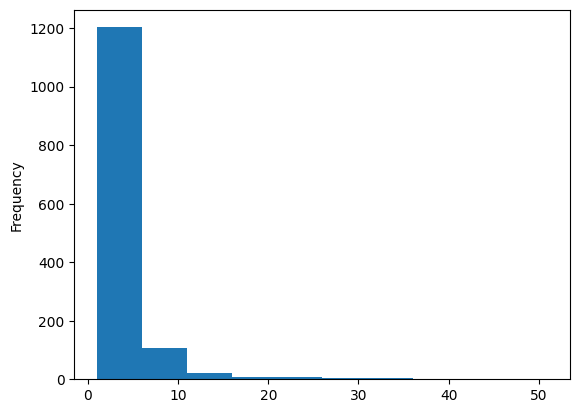

In [ ]:
#plotting the histogram plot to visualize the frequency distribution
df1['seasons'].plot(kind='hist')

<Axes: ylabel='Density'>

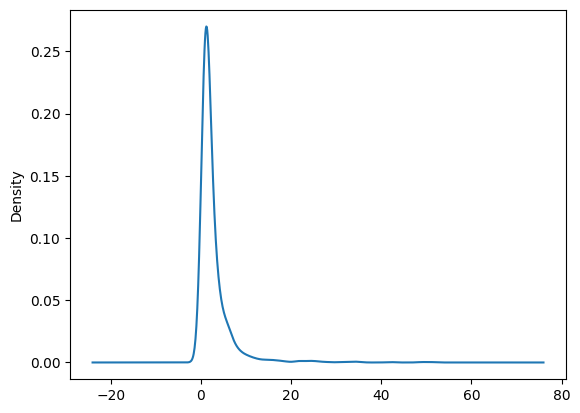

In [ ]:
#plotting the kde plot to check the shape of the distribution
df1['seasons'].plot(kind='kde')

In [ ]:
#checking the percentage of null vaues in the columns
(df1['seasons'].isnull().sum()/len(df1['seasons']))*100

np.float64(86.24847993514389)

### IMDb Score


**Conclusion**
- Mean of the IMDb Score is 5.97.Domination of **average rated** content
- Data in the column is **normally distributed**
- Domination of **average rated** content
- **10%** of the values are missing
- There are some outliers

In [ ]:
#checking the stats of the columns
df1['imdb_score'].describe()

,imdb_score
count,8850.000000
mean,5.976395
std,1.343842
min,1.100000
25%,5.100000
50%,6.100000
75%,6.900000
max,9.900000


<Axes: ylabel='Frequency'>

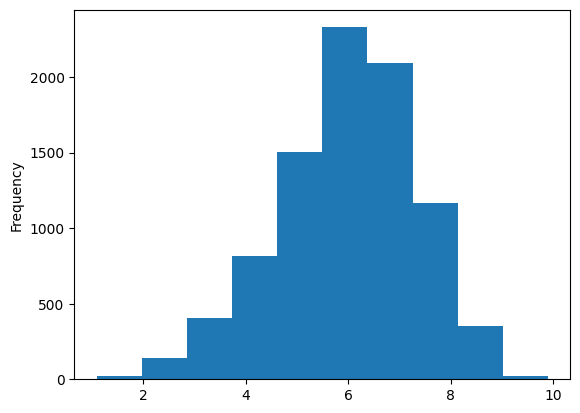

In [ ]:
#plotting the histogram to check the frequency distribution of data in the column
df1['imdb_score'].plot(kind='hist')

<Axes: ylabel='Density'>

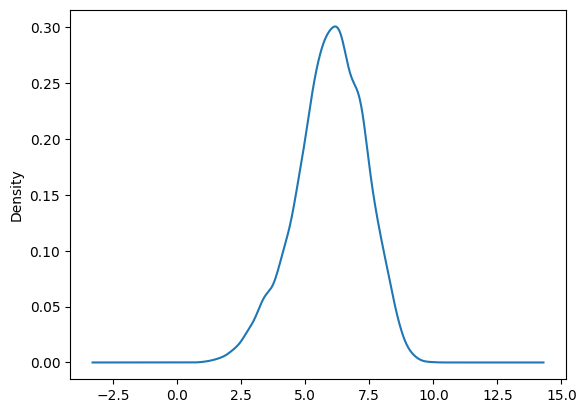

In [ ]:
#plotting the kde plot to check the shape of the distribution
df1['imdb_score'].plot(kind='kde')

In [ ]:
#checking the skewness of the column
df1['imdb_score'].skew()

np.float64(-0.35935094569416104)

<Axes: >

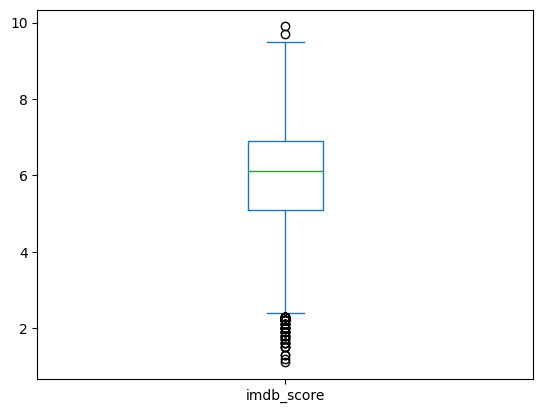

In [ ]:
#plotting the box plot to visualize the outliers
df1['imdb_score'].plot(kind='box')

In [ ]:
#checking the outliers values manually
df1[df1['imdb_score']<3].sort_values('imdb_score')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
7764,tm961646,Finding Jesus,MOVIE,When his daughter is kidnapped in the English ...,2020,G,69,"['family', 'fantasy', 'horror', 'thriller', 'a...",['US'],NaN,tt12981810,1.1,422.0,1.588,1.0
4048,tm37524,Parentesi tonde,MOVIE,"Vanessa, a runaway bride, and Emanuela became ...",2006,NaN,95,"['comedy', 'european']",['IT'],NaN,tt1047512,1.2,144.0,1.578,1.4
4782,tm156948,Saving Christmas,MOVIE,Kirk is enjoying the annual Christmas party ex...,2014,PG,79,"['comedy', 'family']",['US'],NaN,tt4009460,1.3,15844.0,6.296,1.8
4434,ts4032,Fleabag Monkeyface,SHOW,Fleabag Monkeyface is an animated TV show base...,2011,TV-Y7,11,['animation'],['GB'],1.0,tt3857708,1.3,266.0,0.600,NaN
4566,tm177660,Little Bite in the Big City,MOVIE,"Bite, a cockroach who lives in a computer proc...",2011,G,71,"['animation', 'comedy', 'romance']",['RU'],NaN,tt1843957,1.5,154.0,1.135,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9279,tm552220,The Blackout Experiment,MOVIE,6 strangers wake up inside a room garnished wi...,2021,NaN,81,"['horror', 'thriller', 'drama']",['US'],NaN,tt3659284,2.9,239.0,5.200,5.0
9533,tm960865,Tainted Blood,MOVIE,"In a violent criminal underworld, you can't tr...",2021,NaN,80,['horror'],[],NaN,tt13013806,2.9,22.0,NaN,NaN
9362,tm956559,Let's Dream,MOVIE,"Let, a reclusive, insomniac photographer, is h...",2021,NaN,94,"['horror', 'scifi', 'thriller']",['US'],NaN,tt13274918,2.9,127.0,2.606,7.4
9826,tm1080743,Cool Daddy,MOVIE,Tells the story of a man desperately trying to...,2021,NaN,78,"['documentation', 'music']",[],NaN,tt6256050,2.9,14.0,0.600,NaN


In [ ]:
df1[df1['imdb_score']>9]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1159,ts17223,Free to Choose,SHOW,Free to Choose is a ten-part television series...,1980,NaN,57,['documentation'],['US'],2.0,tt0852785,9.2,279.0,1.400,7.8
2001,tm134266,Steven Banks: Home Entertainment Center,MOVIE,"In this brilliant one-man show, the mild-manne...",1989,NaN,60,['comedy'],['US'],NaN,tt0443654,9.1,228.0,0.740,6.4
3950,tm574428,King B.'s Roost 1-2,MOVIE,Chicago Mafia Hit Man Alex Sims finds himself ...,2008,NaN,62,['crime'],['US'],NaN,tt4058628,9.2,12.0,NaN,NaN
5113,ts151280,Subaru Launch Control,SHOW,Go behind closed doors with Subaru Motorsports...,2013,NaN,21,['sport'],[],4.0,tt3923326,9.3,30.0,0.600,NaN
5218,tm178182,A Promise to My Father,MOVIE,We re-trace the steps of Holocaust survivor Is...,2013,NaN,56,['documentation'],['US'],NaN,tt7516502,9.2,8.0,0.600,NaN
6358,ts77883,Surgeons: At the Edge of Life,SHOW,Documentary series going beyond the theatre do...,2018,NaN,59,['documentation'],['GB'],4.0,tt7860280,9.2,96.0,1.519,8.0
6912,ts83241,Harmony with A. R. Rahman,SHOW,Harmony with A.R Rahman' is a curated explorat...,2018,NaN,43,['documentation'],['IN'],1.0,tt8836898,9.1,277.0,0.647,NaN
7422,ts86600,The Chosen,SHOW,The life of Christ through the eyes of those w...,2019,TV-G,47,"['drama', 'history']",['US'],2.0,tt9471404,9.4,25538.0,30.771,9.4
7783,ts231725,Water Helps the Blood Run,SHOW,"Five orphan girls from diverse backgrounds, ca...",2019,NaN,29,"['drama', 'comedy']",[],1.0,tt11524214,9.7,30.0,NaN,NaN
7858,tm810763,Soorarai Pottru,MOVIE,"Nedumaaran Rajangam ""Maara"" sets out to make t...",2020,NaN,149,"['drama', 'action']",['IN'],NaN,tt10189514,9.2,109759.0,4.146,7.9


In [ ]:
print("--Percentage of Null values in the Column--")
(df1['imdb_score'].isnull().sum()/len(df1['imdb_score']))*100

--Percentage of Null values in the Column--


np.float64(10.343430250227941)

### IMDb Votes

**Conclusion**
- Most movies/shows have **low vote counts**, but a few extremely popular titles
  pull the average up.
- This creates extreme outliers
- IMDb votes are heavily **right-skewed**

In [ ]:
#checking the stats of the column
df1['imdb_votes'].describe()

,imdb_votes
count,8.840000e+03
mean,8.533614e+03
std,4.592015e+04
min,5.000000e+00
25%,1.170000e+02
50%,4.625000e+02
75%,2.236250e+03
max,1.133692e+06


In [ ]:
#checking the percentage of the null values
(df1['imdb_votes'].isnull().sum()/len(df1['imdb_votes']))*100

np.float64(10.44473710870226)

<Axes: ylabel='Frequency'>

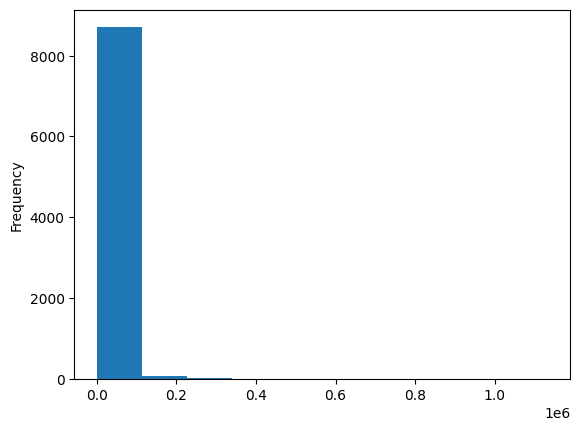

In [ ]:
#plotting the histogram plot to check frequency distribution
df1['imdb_votes'].plot(kind='hist')

<Axes: ylabel='Density'>

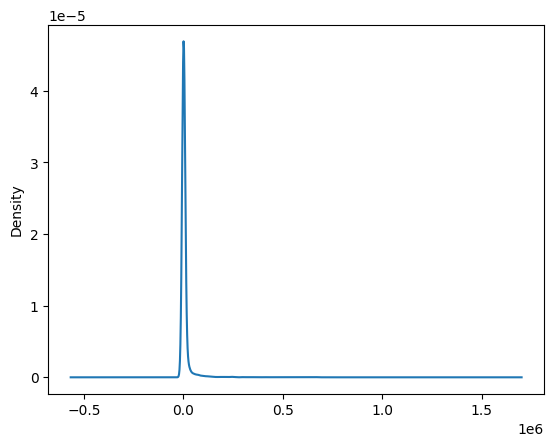

In [ ]:
#plotting the kde plot to check the shape of distribution
df1['imdb_votes'].plot(kind='kde')

In [ ]:
#checking the skewness of the column
df1['imdb_votes'].skew()

np.float64(12.517644817808039)

<Axes: >

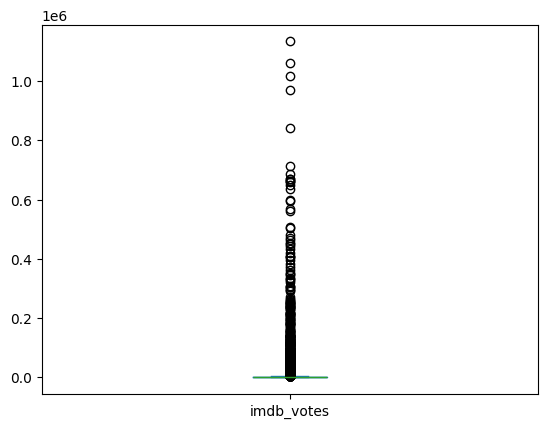

In [ ]:
#plotting the box plot to check the outliers
df1['imdb_votes'].plot(kind='box')

###TMDb Popularity

**Conclusion**
- This column shows an extremely **right-skewed** distribution.
- The box plot indicates that most titles have very **low popularity** values.
- A small number of titles have exceptionally high popularity scores, resulting
  in a large number of high end outliers.
- **5%** values are missing.

In [ ]:
#checking the stats of the column
df1['tmdb_popularity'].describe()

,tmdb_popularity
count,9324.000000
mean,6.910204
std,30.004098
min,0.000011
25%,1.232000
50%,2.536000
75%,5.634000
max,1437.906000


In [ ]:
#checking the percentage of null values in the column
print("-----Percentage of null values in the column-----")
df1['tmdb_popularity'].isnull().sum()/len(df1['tmdb_popularity'])*100

-----Percentage of null values in the column-----


np.float64(5.543169841913255)

<Axes: ylabel='Frequency'>

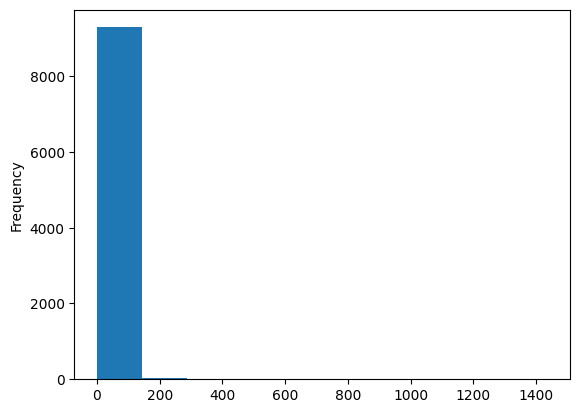

In [ ]:
#plotting the histogram plot to check the frequency distribution
df1['tmdb_popularity'].plot(kind='hist')

<Axes: ylabel='Density'>

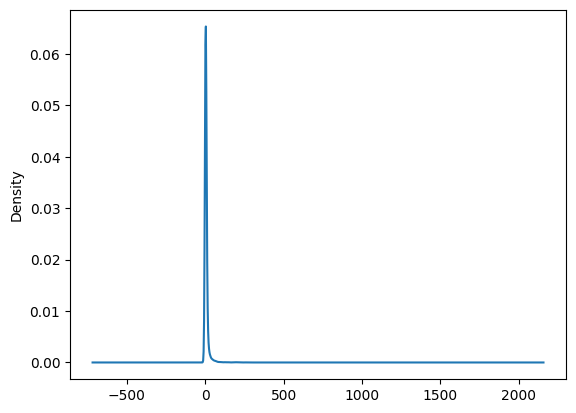

In [ ]:
#plotting the kde plot to check the shape of the distribution
df1['tmdb_popularity'].plot(kind='kde')

In [ ]:
print("---Skewness of the column---")
df1['tmdb_popularity'].skew()

---Skewness of the column---


np.float64(26.77120679871342)

<Axes: >

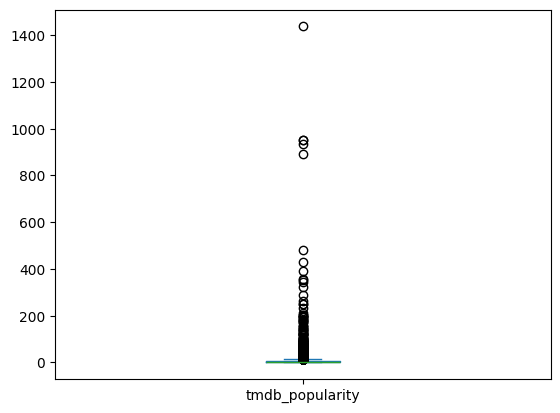

In [ ]:
#plotting the box plot to check the outlier values in the column
df1['tmdb_popularity'].plot(kind='box')

### TMDb Score

**Conclusion**
- Data in the column is **normally distributed**.
- Mean and Median values are indicating towards the domination of **average rated** content.
- Most of the outliers are towards the lower rating content and some content got extremely high rating.
- **Null** values also present in the column which is making **21%** of the column.

In [ ]:
#checking the stats of the column
df1['tmdb_score'].describe()

,tmdb_score
count,7789.000000
mean,5.984247
std,1.517986
min,0.800000
25%,5.100000
50%,6.000000
75%,6.900000
max,10.000000


In [ ]:
print("---Percentage of null values in the column---")
df1['tmdb_score'].isnull().sum()/len(df1['tmdb_score'])*100

---Percentage of null values in the column---


np.float64(21.07823267126064)

<Axes: ylabel='Frequency'>

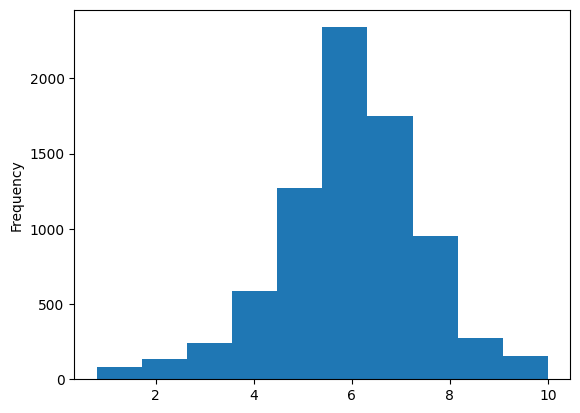

In [ ]:
#plotting the histogram plot to check the frequency distribution
df1['tmdb_score'].plot(kind='hist')

<Axes: ylabel='Density'>

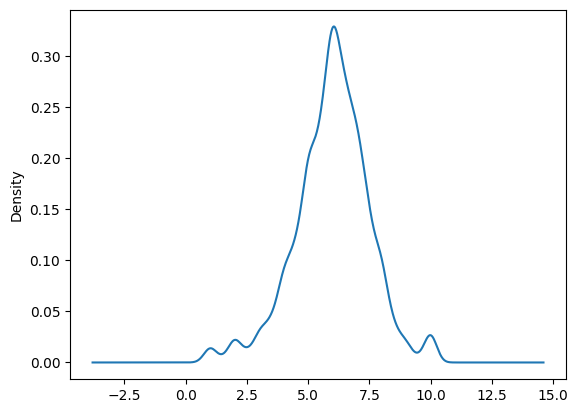

In [ ]:
#plotting the kde plot to check the shape of the distribution
df1['tmdb_score'].plot(kind='kde')

In [ ]:
#checking the skkewness of the column
df1['tmdb_score'].skew()

np.float64(-0.33503346280393337)

<Axes: >

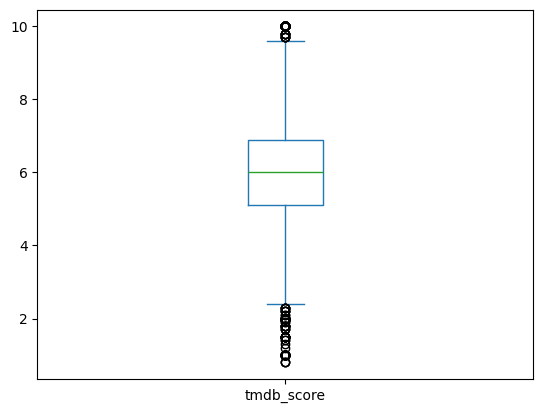

In [ ]:
#plotting the boxplot to check the outliers
df1['tmdb_score'].plot(kind='box')

In [ ]:
#examining the outliers manually
df1[df1['tmdb_score']>=10]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
706,tm80023,Man from Cheyenne,MOVIE,Roy is a government man sent to solve a novel ...,1942,NaN,60,['western'],['US'],NaN,tt0035025,6.5,87.0,1.259,10.0
799,tm63131,Round-Up Time in Texas,MOVIE,Gene and Frog arrive with a herd of horses for...,1937,G,56,"['action', 'western', 'comedy']",['US'],NaN,tt0029501,4.7,232.0,0.880,10.0
1396,ts47033,The New 3 Stooges,SHOW,"Larry, Moe and Curly Joe bring their mastery o...",1965,TV-PG,19,"['comedy', 'animation', 'family']",['US'],1.0,tt0058832,7.0,334.0,3.110,10.0
1585,tm180755,Server Sundaram,MOVIE,"Sundaram, a hotel employee, dreams of becoming...",1964,NaN,165,"['comedy', 'drama', 'romance']",['IN'],NaN,tt0234697,7.8,321.0,4.805,10.0
1586,tm104834,Eagles Attack At Dawn,MOVIE,Eli is an Israeli soldier who manages to escap...,1970,PG,90,"['action', 'drama', 'war']",['IL'],NaN,tt0073089,4.3,131.0,0.873,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9654,ts287826,Qing Luo,SHOW,Yu Qing Luo gives birth to a son named Nan Nan...,2021,NaN,40,"['drama', 'romance', 'comedy', 'history']",['CN'],1.0,tt14923202,8.3,17.0,5.848,10.0
9703,tm1033158,Kuriyan Jawan Bapu Preshaan,MOVIE,"Fatherhood is a massive responsibility, howeve...",2021,NaN,108,"['comedy', 'drama']",['IN'],NaN,tt14303124,6.1,196.0,1.256,10.0
9719,tm1031868,Memories of Reality,MOVIE,Jacob is quickly digressing into a state of in...,2021,NaN,98,"['drama', 'thriller']",['US'],NaN,NaN,NaN,NaN,1.106,10.0
9739,ts304204,Pinkfong Job Songs,SHOW,What do you want to be when you grow up? Follo...,2021,TV-Y,2,[],['KR'],1.0,NaN,NaN,NaN,0.600,10.0


In [ ]:
df1[df1['tmdb_score']>9.5]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
706,tm80023,Man from Cheyenne,MOVIE,Roy is a government man sent to solve a novel ...,1942,NaN,60,['western'],['US'],NaN,tt0035025,6.5,87.0,1.259,10.0
799,tm63131,Round-Up Time in Texas,MOVIE,Gene and Frog arrive with a herd of horses for...,1937,G,56,"['action', 'western', 'comedy']",['US'],NaN,tt0029501,4.7,232.0,0.880,10.0
1396,ts47033,The New 3 Stooges,SHOW,"Larry, Moe and Curly Joe bring their mastery o...",1965,TV-PG,19,"['comedy', 'animation', 'family']",['US'],1.0,tt0058832,7.0,334.0,3.110,10.0
1585,tm180755,Server Sundaram,MOVIE,"Sundaram, a hotel employee, dreams of becoming...",1964,NaN,165,"['comedy', 'drama', 'romance']",['IN'],NaN,tt0234697,7.8,321.0,4.805,10.0
1586,tm104834,Eagles Attack At Dawn,MOVIE,Eli is an Israeli soldier who manages to escap...,1970,PG,90,"['action', 'drama', 'war']",['IL'],NaN,tt0073089,4.3,131.0,0.873,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9654,ts287826,Qing Luo,SHOW,Yu Qing Luo gives birth to a son named Nan Nan...,2021,NaN,40,"['drama', 'romance', 'comedy', 'history']",['CN'],1.0,tt14923202,8.3,17.0,5.848,10.0
9703,tm1033158,Kuriyan Jawan Bapu Preshaan,MOVIE,"Fatherhood is a massive responsibility, howeve...",2021,NaN,108,"['comedy', 'drama']",['IN'],NaN,tt14303124,6.1,196.0,1.256,10.0
9719,tm1031868,Memories of Reality,MOVIE,Jacob is quickly digressing into a state of in...,2021,NaN,98,"['drama', 'thriller']",['US'],NaN,NaN,NaN,NaN,1.106,10.0
9739,ts304204,Pinkfong Job Songs,SHOW,What do you want to be when you grow up? Follo...,2021,TV-Y,2,[],['KR'],1.0,NaN,NaN,NaN,0.600,10.0


In [ ]:
df1[df1['tmdb_score']<1]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
4481,tm308363,Girls Like Us,MOVIE,Keisha is intimately involved in two relations...,2012,NaN,74,"['comedy', 'drama', 'romance']",['US'],NaN,tt2387006,5.6,30.0,0.992,0.8
5429,ts39160,Fluffy's Food Adventures,SHOW,"Comedian Gabriel ""Fluffy"" Iglasias and his ent...",2015,TV-MA,20,"['comedy', 'reality']",['US'],3.0,tt5163450,7.2,184.0,6.686,0.8
9147,tm1087081,Demented,MOVIE,"For one female entity time stands still, while...",2021,NaN,90,"['horror', 'thriller']",['CA'],NaN,tt6243370,6.5,2128.0,2.567,0.8


### **Analysis of Categorical Columns**




### Types

**Conclusion**
- The dataset is highly dominated by the **Movies(86.3%)**.
- **Scarcity** of TV Shows.

In [ ]:
df1['type'].value_counts()

,count
type,
MOVIE,8514
SHOW,1357


<Axes: xlabel='type'>

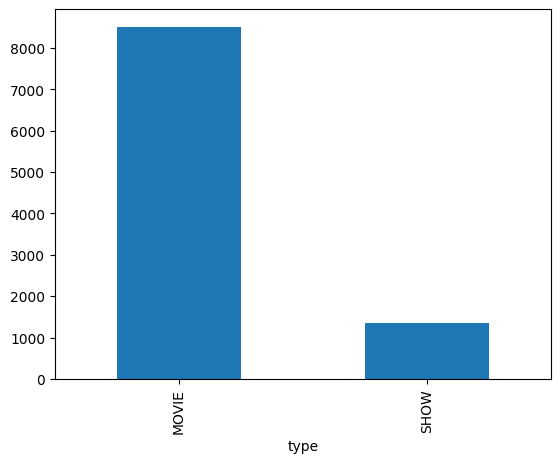

In [ ]:
df1['type'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

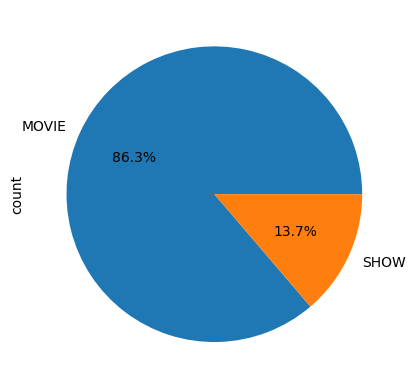

In [ ]:
df1['type'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [ ]:
print("--Total null values in the column--")
df1['type'].isnull().sum()

--Total null values in the column--


np.int64(0)

### Age Cerification

**Conclusion**
- The dataset is heavily dominated by mature content, with **R-rated**(restricted) for movies and **TV-MA**(mature audience only)for TV Shows forming the largest share.
- Family- friendly content such as **G**(general audience), **TV-Y**(suitable for all children), and **TV-Y7** (suitable for children 7+) exist but is comparatively limited, while **NC-17**(Adults only) is extremely rare.
- This column contains approximately **65% missing values**, which significantlly limits its reliability for dataset-wide analysis.

In [ ]:
df1['age_certification'].value_counts()

,count
age_certification,
R,1249
PG-13,588
PG,582
G,269
TV-MA,217
TV-14,188
TV-PG,91
TV-Y,78
TV-G,57


Text(0.5, 1.0, 'Distribution of Age Certification')

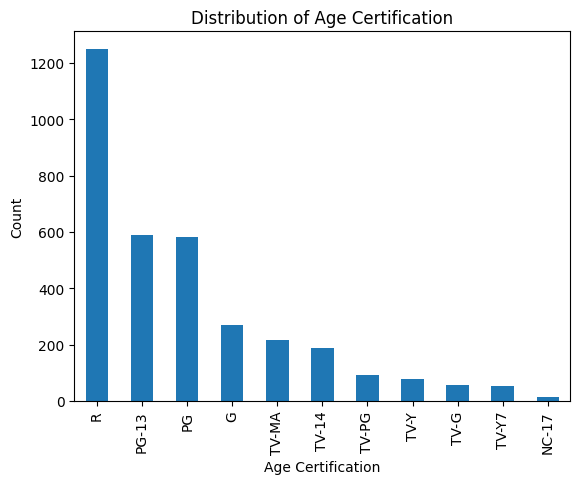

In [ ]:
df1['age_certification'].value_counts().plot(kind='bar')
plt.xlabel('Age Certification')
plt.ylabel('Count')
plt.title('Distribution of Age Certification')

Text(0.5, 1.0, 'Distribution of Age Certification')

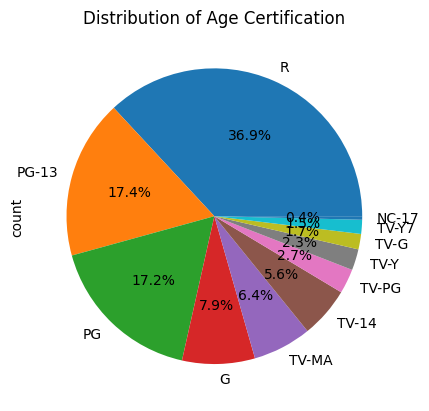

In [ ]:
df1['age_certification'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.title('Distribution of Age Certification')

In [ ]:
print("--percentage of null values--")
(df1['age_certification'].isnull().sum()/len(df1['age_certification']))*100

--percentage of null values--


np.float64(65.70733684637212)

### Genres


**Conclusion**
- Object-type column.
- It was cleaned by extracting relevant values and standardizing formats to
ensure consistency and usability.
- After analysing through the bar graph and pie chart the dominant genres are **Drama(21.6%)** and **Comedy(13.5%)**.
- **Thriller**, **Action** and **Romance** also making their presence in a significant manner. Making around 25% of the column.
- There are some null values also, which is making barely 1% of the column.

In [ ]:
df1['genres'].value_counts()

,count
genres,
['drama'],908
['comedy'],686
['documentation'],493
['horror'],217
[],209
...,...
"['thriller', 'action', 'romance']",1
"['thriller', 'crime', 'action', 'european', 'drama']",1
"['horror', 'thriller', 'scifi', 'crime']",1


In [ ]:
df1['genres'].dtype

dtype('O')

In [ ]:
# importing ast(abstract syntax tree)
# using ast.literal() function since it safely converts a string into a real python object
import ast
def safe_eval(x):
  if isinstance(x, str):
    try:
      return ast.literal_eval(x)
    except:
      return []
  return x
df1['genres']=df1['genres'].apply(safe_eval)
df_exp=df1.explode('genres')
df_exp['genres'].value_counts()

,count
genres,
drama,4762
comedy,2987
thriller,2119
action,1820
romance,1751
crime,1250
documentation,1096
horror,1065
family,751


Text(0, 0.5, 'Count')

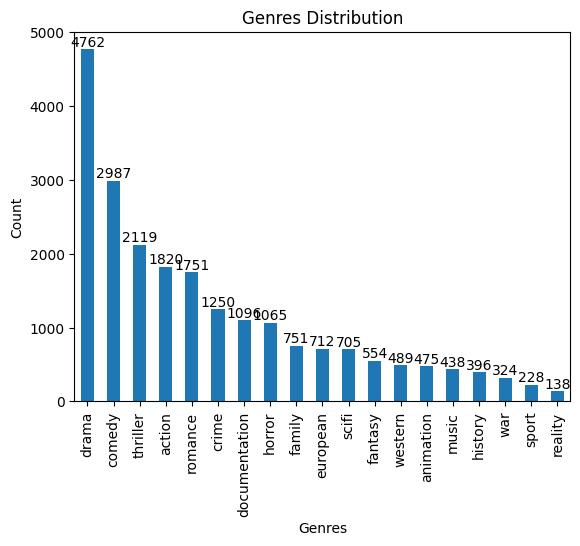

In [ ]:
ax=df_exp['genres'].value_counts().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Genres Distribution')
ax.set_xlabel('Genres')
ax.set_ylabel('Count')




Text(0.5, 1.0, 'Genres Distribution')

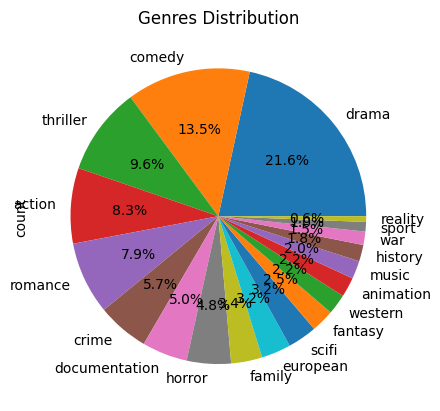

In [ ]:
df_exp['genres'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.title('Genres Distribution')


In [ ]:
print("--Percentage of Null values in the Column--")
(df_exp['genres'].isnull().sum()/len(df_exp['genres']))*100

--Percentage of Null values in the Column--


np.float64(0.9385244061251066)

### Production Countries

**Conclusion**

- Object-type column.

- After doing cleaning,it was found that **US** is the biggest contributer to the dataset with **almost 60%** of the content dominated by the US.

- **IN** and **GB** also contribute a significant content **(almost 23%)** as compare to other countries.

In [ ]:
df1['production_countries'].describe()

,production_countries
count,9868
unique,497
top,['US']
freq,4807


In [ ]:
df1['production_countries']

,production_countries
0,['US']
1,['US']
2,['US']
3,['US']
4,['US']
...,...
9866,['US']
9867,['US']
9868,['IN']
9869,[]


In [ ]:
df1['production_countries'].dtype

dtype('O')

In [ ]:
df1['production_countries']=df1['production_countries'].apply(safe_eval)
df_exp=df1.explode('production_countries')
df_exp['production_countries'].value_counts()

,count
production_countries,
US,5331
IN,1072
GB,928
CA,530
FR,250
...,...
EC,1
AM,1
SY,1


<Axes: xlabel='production_countries'>

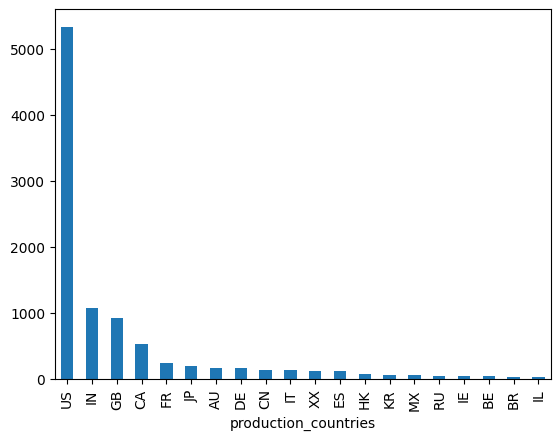

In [ ]:
df_exp['production_countries'].value_counts().head(20).plot(kind='bar')

<Axes: ylabel='count'>

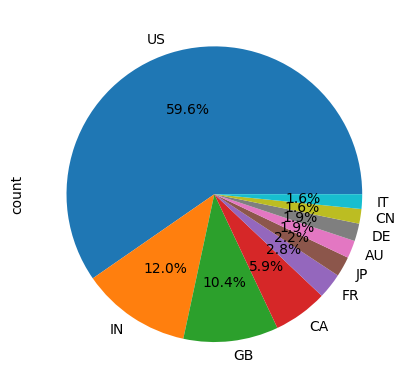

In [ ]:
df_exp['production_countries'].value_counts().head(10).plot(kind='pie',autopct='%0.1f%%')

### **Analysis of Mixed Columns**

### ID

**Conclusion**
- The id column contains unique identifiers for each record. Since it has no
repetition or analytical significance, it was excluded from further analysis.

In [ ]:
df1['id'].describe()

,id
count,9868
unique,9868
top,ts275838
freq,1


### Title

**Conclusion**
- This column contains the titles name of movies and show.
- It contains **131 duplicates**.
- After analysing duplicate in titles, it was found that despite being the same title name some columns like release_year, production country, description and type are different.
- So, instead of dropping, keeping this column for further analysis.

In [ ]:
df1['title'].describe()

,title
count,9868
unique,9737
top,The Lost World
freq,3


In [ ]:
df1['title'].isnull().sum()

np.int64(0)

In [ ]:
df1['title'].duplicated().sum()

np.int64(131)

In [ ]:
df1[df1['title'].duplicated()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
472,tm99134,Little Men,MOVIE,The former Jo March and her husband Professor ...,1934,NaN,72,"['romance', 'drama']",['US'],NaN,tt0026636,6.2,78.0,1.217,4.0
904,tm111211,Custer's Last Stand,MOVIE,Kit Cardigan seeks the killer of his father......,1936,NaN,328,"['western', 'history', 'romance', 'war']",['US'],NaN,tt0126256,4.7,235.0,0.945,4.0
1230,tm104962,Wuthering Heights,MOVIE,The Earnshaws are Yorkshire farmers during the...,1970,G,104,"['drama', 'romance']",['GB'],NaN,tt0066585,6.4,1924.0,3.039,6.6
1944,ts1000,Alice in Wonderland,SHOW,One of the most well-known stories begins one ...,1986,NaN,29,"['scifi', 'fantasy']",['GB'],1.0,tt0421576,7.2,73.0,0.600,7.0
1972,tm23704,Beauty and the Beast,MOVIE,"To save her father, a girl who always puts oth...",1987,G,94,"['romance', 'fantasy', 'family']","['IL', 'US']",NaN,tt0092626,5.9,704.0,7.363,6.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9373,tm1133705,Bali,MOVIE,This movie is about the life of a middle class...,2021,NaN,103,"['thriller', 'horror']",['IN'],NaN,tt14194044,6.5,296.0,1.696,NaN
9449,tm1069739,Mind Games,MOVIE,An Army psychologist held captive by an unknow...,2021,NaN,99,['thriller'],['US'],NaN,NaN,NaN,NaN,2.830,7.0
9550,ts296284,Truth or Dare,SHOW,A story that follows two couples who mistakenl...,2021,NaN,36,['comedy'],['CN'],1.0,NaN,NaN,NaN,8.358,7.0
9761,tm1102439,Udanpirappe,MOVIE,A woman hopes for the reunion of two families ...,2021,NaN,137,['drama'],['IN'],NaN,NaN,NaN,NaN,1.579,5.0


In [ ]:
df1[df1['title'].duplicated(keep=False)]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
15,tm155610,Wuthering Heights,MOVIE,The Earnshaws are Yorkshire farmers during the...,1939,NaN,104,"['drama', 'romance']",['US'],NaN,tt0032145,7.5,17956.0,12.336,7.3
46,tm140761,The Lost World,MOVIE,The first film adaptation of Sir Arthur Conan ...,1925,NaN,93,"['fantasy', 'thriller', 'scifi']",['US'],NaN,tt0016039,7.0,5185.0,8.026,6.7
69,tm109275,Dr. Jekyll and Mr. Hyde,MOVIE,A doctor's research into the roots of evil tur...,1920,NaN,79,"['horror', 'scifi', 'drama']",['US'],NaN,tt0011130,6.9,5367.0,8.160,7.0
75,tm91719,Let There Be Light,MOVIE,The final entry in a trilogy of films produced...,1946,NaN,58,"['war', 'documentation']",['US'],NaN,tt0082649,7.4,1850.0,3.226,7.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9449,tm1069739,Mind Games,MOVIE,An Army psychologist held captive by an unknow...,2021,NaN,99,['thriller'],['US'],NaN,NaN,NaN,NaN,2.830,7.0
9550,ts296284,Truth or Dare,SHOW,A story that follows two couples who mistakenl...,2021,NaN,36,['comedy'],['CN'],1.0,NaN,NaN,NaN,8.358,7.0
9560,tm1090237,Udanpirappe,MOVIE,A woman hopes for the reunion of two families ...,2021,NaN,137,['drama'],[],NaN,tt15175418,5.1,871.0,NaN,NaN
9761,tm1102439,Udanpirappe,MOVIE,A woman hopes for the reunion of two families ...,2021,NaN,137,['drama'],['IN'],NaN,NaN,NaN,NaN,1.579,5.0


In [ ]:
df1[df1['title']=='Wuthering Heights']

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
15,tm155610,Wuthering Heights,MOVIE,The Earnshaws are Yorkshire farmers during the...,1939,NaN,104,"['drama', 'romance']",['US'],NaN,tt0032145,7.5,17956.0,12.336,7.3
1230,tm104962,Wuthering Heights,MOVIE,The Earnshaws are Yorkshire farmers during the...,1970,G,104,"['drama', 'romance']",['GB'],NaN,tt0066585,6.4,1924.0,3.039,6.6


In [ ]:
df1[df1['title']=='The Three Stooges']

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
2406,tm22932,The Three Stooges,MOVIE,"A biography of the Three Stooges, in which the...",2000,NaN,88,"['drama', 'comedy']",['US'],NaN,tt0214698,6.9,2011.0,3.582,7.0


In [ ]:
df1[df1['title']=='The Lost World']

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
46,tm140761,The Lost World,MOVIE,The first film adaptation of Sir Arthur Conan ...,1925,NaN,93,"['fantasy', 'thriller', 'scifi']",['US'],NaN,tt0016039,7.0,5185.0,8.026,6.7
2716,tm125641,The Lost World,MOVIE,"Unfazed by ridicule from fellow scientists, pr...",1992,NaN,99,"['scifi', 'action', 'fantasy']",['CA'],NaN,tt0104759,5.3,1187.0,3.991,5.8
3399,tm44321,The Lost World,MOVIE,This Lost World is a splendid BBC TV dramatisa...,2001,NaN,150,"['fantasy', 'scifi', 'drama']","['DE', 'GB', 'US']",NaN,tt0302739,6.6,2876.0,6.240,6.0


In [ ]:
df1[df1['title']=='Dr. Jekyll and Mr. Hyde']

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
69,tm109275,Dr. Jekyll and Mr. Hyde,MOVIE,A doctor's research into the roots of evil tur...,1920,NaN,79,"['horror', 'scifi', 'drama']",['US'],NaN,tt0011130,6.9,5367.0,8.160,7.0
3256,tm58493,Dr. Jekyll and Mr. Hyde,MOVIE,Dr. Henry Jekyll is a well-regarded physician ...,2008,PG,89,"['horror', 'scifi', 'thriller']",['CA'],NaN,tt1159984,4.6,1272.0,6.248,4.6


### Description

**Conclusion**
- Almost entire column is filled with unique values except 133 duplicated values.
- However most duplicates arise from placeholder text rather than true data
repetition.
- This column will help us finding the true duplicated values from title column for further analysis.

In [ ]:
df1['description'].describe()

,description
count,9749
unique,9734
top,No overview found.
freq,5


In [ ]:
print("--Total null values in the column--")
df1['description'].isnull().sum()

--Total null values in the column--


np.int64(119)

In [ ]:
print("--Total duplicated values--")
df1['description'].duplicated().sum()

--Total duplicated values--


np.int64(133)

In [ ]:
#Examing the duplicated values
dup_desc=df1[df1['description'].notna() & df1['description'].duplicated(keep=False)]
dup_desc.sort_values(by='description')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
2010,tm205047,Gallagher: the Bookkeeper,MOVIE,"A live performance by ""Sledge-O-Matic"" stand-u...",1985,NaN,58,"['documentation', 'comedy']",['US'],NaN,tt0281875,8.1,90.0,0.887000,NaN
2120,tm63573,Gallagher: Stuck in the 60's,MOVIE,"A live performance by ""Sledge-O-Matic"" stand-u...",1983,NaN,50,"['comedy', 'documentation']",['US'],NaN,tt0284139,7.4,115.0,0.600000,3.3
2160,tm204921,Gallagher: Over Your Head,MOVIE,"A live performance by ""Sledge-O-Matic"" stand-u...",1984,NaN,58,"['comedy', 'documentation']",['US'],NaN,tt0284138,7.3,84.0,0.600000,3.0
8631,tm857922,Local Boy,MOVIE,A petty thief learns about his father's illust...,2020,NaN,142,"['action', 'drama']",[],NaN,NaN,NaN,NaN,0.600000,NaN
8312,tm849043,Pattas,MOVIE,A petty thief learns about his father's illust...,2020,NaN,142,['action'],['IN'],NaN,NaN,NaN,NaN,2.588000,6.8
6128,tm432922,The Bath Song & More Kids Songs: Super Simple ...,MOVIE,A selection of 20 of the most loved Super Simp...,2015,NaN,41,['animation'],[],NaN,NaN,NaN,NaN,0.600000,NaN
6125,tm432932,Do You Like Broccoli Ice Cream? & More Kids So...,MOVIE,A selection of 20 of the most loved Super Simp...,2015,NaN,48,['animation'],[],NaN,NaN,NaN,NaN,0.600000,NaN
2603,tm191223,Daar,MOVIE,A woman is caught between one man's love and a...,1993,NaN,178,"['thriller', 'action', 'drama', 'romance']",[],NaN,tt0109555,7.6,23591.0,0.000153,7.1
2588,tm184335,Darr,MOVIE,A woman is caught between one man's love and a...,1993,R,179,"['romance', 'thriller', 'action']",['IN'],NaN,NaN,NaN,NaN,3.964000,6.9
9572,tm1049084,Mixed Up,MOVIE,Add a Plot »,2021,NaN,106,['drama'],[],NaN,tt13030804,NaN,NaN,NaN,NaN


### IMDb ID

**Conclusion**
-The id column contains unique identifiers for each record. Since it has no repetition or analytical significance, it was excluded from further analysis.


In [ ]:
df1['imdb_id'].describe()

,imdb_id
count,9201
unique,9201
top,tt13542552
freq,1


### **Bivariate & Multivariate Analysis**
**Bivariate Analysis**- Bivariate analysis is the statistical **examination of** **two variables** to determine the relationship, association, or correlation between them.

**Charts used in Bivariate Analysis**- Scatter Plot, Line Graph, Bar Chart, Stacked Bar Chart, Box Plot, HeatMap

**Multivartiate Analysis**-Multivariate analysis **examines more than two** **variables** at the same time to understand complex relationships and effects.

**Charts used in Multivariate Analysis**:- 3D Scatter Plot, Multivariate Line Chart,
Bubble Chart, Pair Plot, HeatMap



### IMDb Votes & IMDb Score

**Conclusion**
- There is a **weak-to-moderate positive** relationship between IMDb score and vote count.
- Most titles receive relatively **low votes**, with only a small proportion achieving very high popularity.
- Movies tend to accumulate more votes compared to shows.
- Highly voted titles are generally rated above 7.

In [ ]:
df1[['imdb_score', 'imdb_votes']].isnull().sum()

,0
imdb_score,1021
imdb_votes,1031


Text(0.5, 1.0, 'IMDb Votes vs IMDb Score')

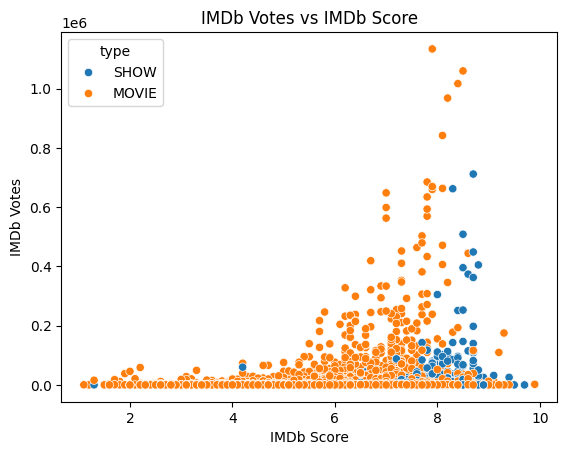

In [ ]:
df_clean=df1.dropna(subset=['imdb_score', 'imdb_votes'])
sns.scatterplot(x='imdb_score', y='imdb_votes', hue='type', data=df_clean)
plt.xlabel('IMDb Score')
plt.ylabel('IMDb Votes')
plt.title('IMDb Votes vs IMDb Score')


In [ ]:
print("--Correlation--")
df_clean['imdb_votes'].corr(df_clean['imdb_score'])

--Correlation--


np.float64(0.1658924076453243)

### Release Year vs IMDb Score

**Conclusion**
- No strong upward or downward long-term trend.
- Ratings mostly revolve around 6.0 across decades.
- Early years and some recent years show higher variability.
- Movie ratings are relatively stable over history.

In [ ]:
df1[['release_year', 'imdb_score']].isnull().sum()


,0
release_year,0
imdb_score,1021


Text(0.5, 1.0, 'Average IMDb Score Trend')

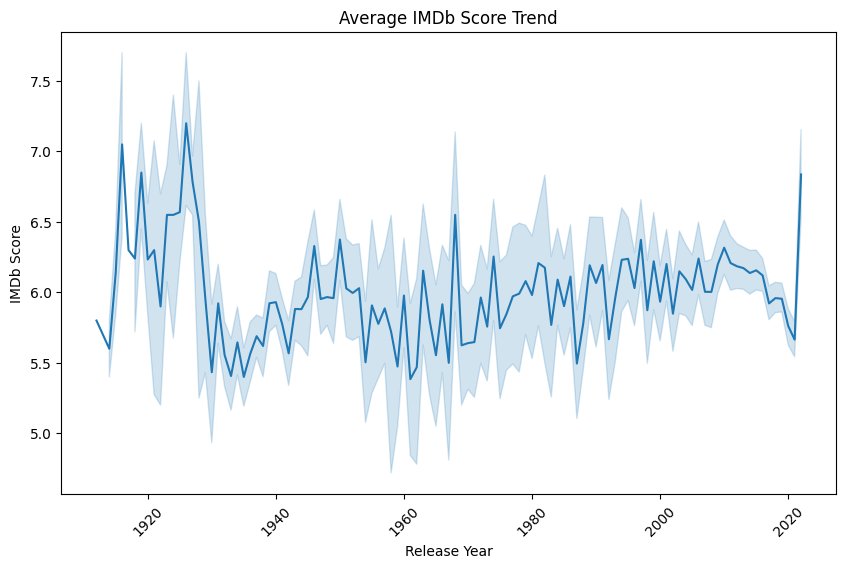

In [ ]:

ax=df1.dropna(subset=['release_year', 'imdb_score'])
plt.figure(figsize=(10,6))
sns.lineplot(data=ax, x='release_year', y='imdb_score')
plt.xlabel('Release Year')
plt.ylabel('IMDb Score')
plt.xticks(rotation=45)
plt.title('Average IMDb Score Trend')

In [ ]:
#dropping the null values from both the column
ax=df1.dropna(subset=['release_year', 'imdb_score'])
yearly_votes=ax.groupby('release_year')['imdb_score'].mean().reset_index()
#plotting the line graph
fig=px.line(yearly_votes, x='release_year', y='imdb_score', title=
            'Release Yesar vs IMDb score')
fig.show()

### Age Certification vs IMDb Votes

**Conclusion**
- Genres like **PG-13**(Parental Guidance under 13), **R**(Restricted), **TV-14**(Not Suitable for Under 14) and **TV-MA**(Mature Audience Only) getting more audience.
- Majority of the mature content coming from the **US**.
- This variable contains approximately **65% missing values**, which significantlly limits the reliability of insights derived from it.

In [ ]:
print("-----percentage of null values in age certification column-----")
(df1['age_certification'].isnull().sum()/len(df1['age_certification']))*100

-----percentage of null values in age certification column-----


np.float64(65.70733684637212)

Text(0.5, 1.0, 'Avg IMDb Votes by Age Certification')

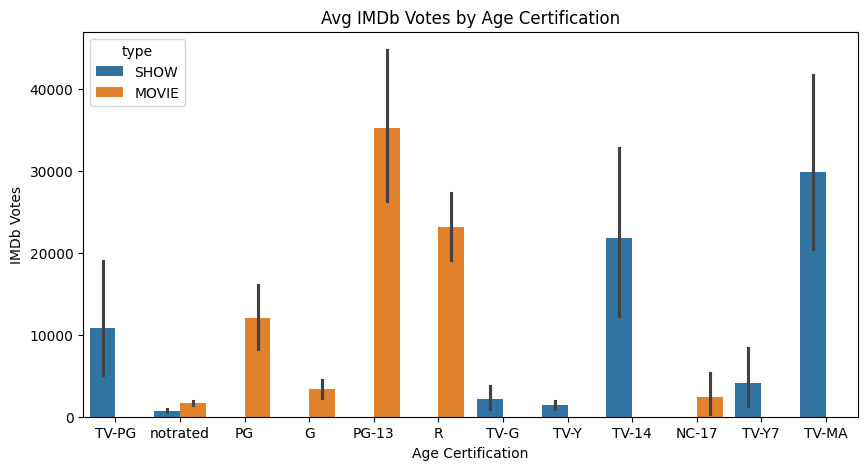

In [ ]:
df1['age_certification']=df1['age_certification'].fillna('notrated')
plt.figure(figsize=(10,5))
sns.barplot(data=df1, x='age_certification', y='imdb_votes', hue='type')
plt.xlabel('Age Certification')
plt.ylabel('IMDb Votes')
plt.title('Avg IMDb Votes by Age Certification')



In [ ]:
df1['production_countries']=df1['production_countries'].apply(safe_eval)
df_exp=df1.explode('production_countries')
#filling null values
df_exp['age_certification']=df_exp['age_certification'].fillna('notrated')
#removing null values
df_exp=df_exp.dropna(subset=['imdb_votes'])
ax=(df_exp.groupby(['age_certification', 'production_countries'])['imdb_votes'].sum().reset_index())
# Creating stacked bar chart with the help of ploty
fig = px.bar(ax, x='age_certification', y='imdb_votes', color='production_countries',
             barmode='stack', title='Total imdb votes by Age Certification and Countries')
fig.show()


**Top 5 countries Producing Mature Audience Content**

Text(0.5, 1.0, 'Top 5 Countries Producing Mature Audience Content')

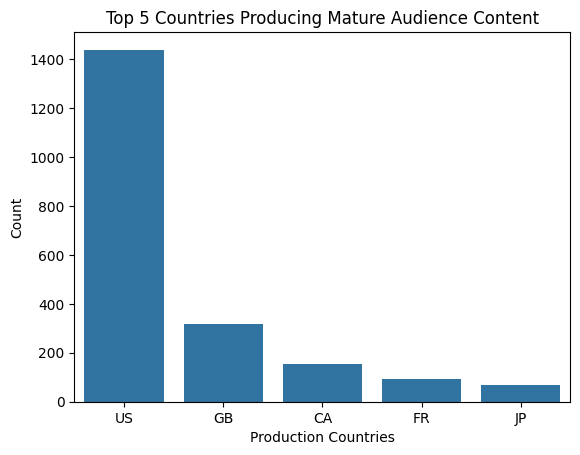

In [ ]:
dfx=df_exp[df_exp['age_certification'].isin(['PG-13', 'R', 'TV-14', 'TV-MA'])]
dfy=dfx['production_countries'].value_counts().reset_index().head(5)
sns.barplot(data=dfy, x='production_countries', y='count')
plt.xlabel('Production Countries')
plt.ylabel('Count')
plt.title('Top 5 Countries Producing Mature Audience Content')


### IMDb Score vs TMDb Score

**Conclusion**
- Moderate positive correlationship.

- As IMDb score increases, TMDb score also tends to increase.
- Most points are are concentrated around **4-7** on both the platform. Which means
majority of Amazon content is **average-rated**.


In [ ]:
#checking the total null values
df1[['imdb_score', 'tmdb_score']].isnull().sum()

,0
imdb_score,1021
tmdb_score,2082


In [ ]:
#dropping the null values from both the columns
imdb_tmdb=df1[['imdb_score', 'tmdb_score']].dropna()

Text(0.5, 1.0, 'IMDb Score vs TMDb Score')

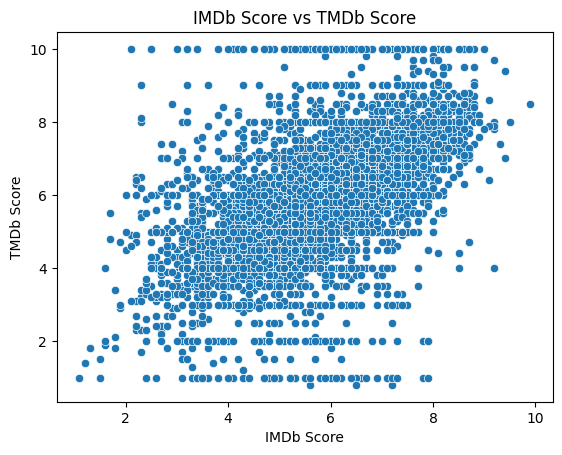

In [ ]:
sns.scatterplot(data=imdb_tmdb, x='imdb_score', y='tmdb_score')
plt.xlabel('IMDb Score')
plt.ylabel('TMDb Score')
plt.title('IMDb Score vs TMDb Score')


In [ ]:
print("-----correlation between imdb score and tmdb score-----")
df1['imdb_score'].corr(df1['tmdb_score'])

-----correlation between imdb score and tmdb score-----


np.float64(0.5809900275457208)

### Release Year vs IMDb Votes

**Conclusion**

- The scatter plot of Release Year versus IMDb votes shows a weak positive trend.
- **Post-2000** films dominate in quantity and vote count.
- Content from the **67 new countries** are added after the **year 2000.**

- There is a large spread of votes within the same year.

In [ ]:
#checking the null values
df1[['imdb_votes','release_year']].isnull().sum()

,0
imdb_votes,1031
release_year,0


In [ ]:
#dropping the null values before plotting the graph
df_plot=df1.dropna(subset=['imdb_votes', 'release_year'])

,imdb_votes
0,1092.0
1,89766.0
2,63026.0
3,57835.0
4,30924.0
...,...
9862,1188.0
9863,50.0
9864,142.0
9866,20.0


Text(0.5, 1.0, 'Release Year vs IMDb Votes')

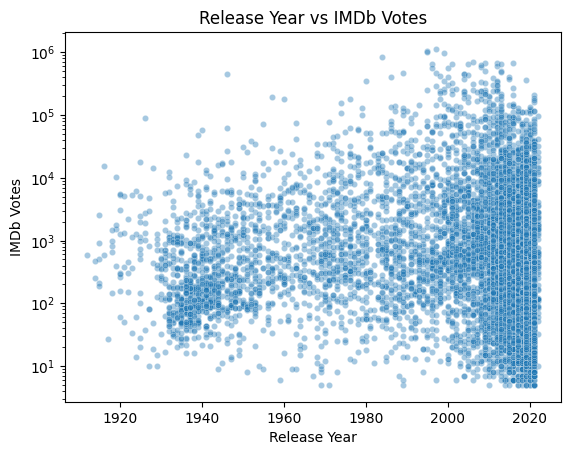

In [ ]:
df_plot=df1.dropna(subset=['imdb_votes', 'release_year'])
sns.scatterplot(data=df_plot, x='release_year', y='imdb_votes', alpha=0.4, s=20)
plt.yscale('log')
plt.xlabel('Release Year')
plt.ylabel('IMDb Votes')
plt.title('Release Year vs IMDb Votes')

Checking New Countries after the **Year 2000**

In [ ]:
# applying the safe_eval function on production countries column
df1['production_countries']=df1['production_countries'].apply(safe_eval)
df_exp=df1.explode('production_countries')
# using the filter in which release year is less than 2000
ax=df_exp[df_exp['release_year']<2000]
#checking the count of the countries by using index
bx=ax['production_countries'].value_counts().reset_index(name='count')
print("Total Countries before the year 2000")
bx

Total Countries before the year 2000


,production_countries,count
0,US,2122
1,GB,211
2,IN,145
3,CA,73
4,IT,72
5,FR,46
6,DE,45
7,JP,41
8,HK,31
9,ES,27


In [ ]:
# Now counting the total production countries after the year 2000
cx=df_exp[df_exp['release_year']>=2000]
dx=cx['production_countries'].value_counts().reset_index(name='count')
dx

,production_countries,count
0,US,3209
1,IN,927
2,GB,717
3,CA,457
4,FR,204
...,...,...
105,EC,1
106,AM,1
107,SY,1
108,CM,1


In [ ]:
# Extracting the newly added countries which was added after the year 2000
# Tilde(~) used to extract the newly added countries from both the dataframe
ex=dx[~dx['production_countries'].isin(bx['production_countries'])]
ex

,production_countries,count
19,NG,29
22,NO,25
26,TH,22
30,PL,18
33,IR,12
...,...,...
105,EC,1
106,AM,1
107,SY,1
108,CM,1


Plotting the **Line Graph** with the help of **Plotly**

In [ ]:
#dropping the null values
df_plot=df1.dropna(subset=['imdb_votes', 'release_year'])
#Grouping the data on yearly bases and getting the avg of imdb votes
yearly_votes=df_plot.groupby('release_year')['imdb_votes'].mean().reset_index()
#plotting the line graph
fig=px.line(yearly_votes, x='release_year', y='imdb_votes', title=
            'Release Yesar vs IMDb Vote')
fig.update_yaxes(type='log')
fig.show()

In [ ]:
ax=df_plot[df_plot['release_year']==1995]
ax['release_year'].value_counts()

,count
release_year,
1995,47


### IMDb Votes vs Genres

**Conclusion**
- Genres like **SciFi** and **War** getting more audience.
- Whereas **Western**, **Reality**, and **Documentation** genres getting less audience.

In [ ]:
#checking the null values
df1[['imdb_votes','genres']].isnull().sum()

,0
imdb_votes,1031
genres,0


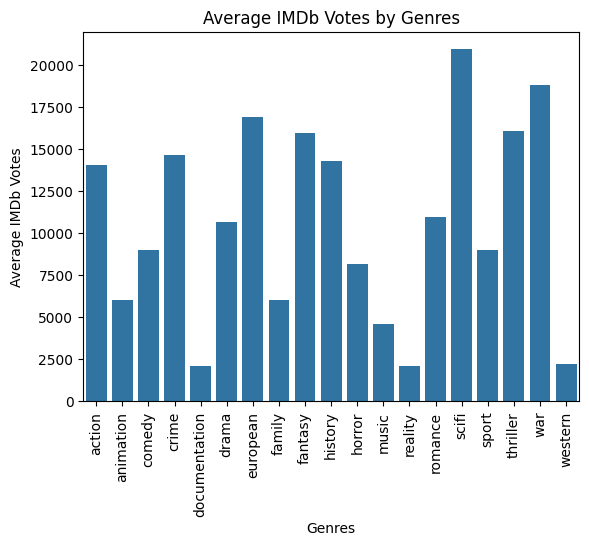

In [ ]:
# applying safe_eval function on genres column
df1['genres']=df1['genres'].apply(safe_eval)
# extracting all the genres using explode method
df_exp=df1.explode('genres')
#dropping all the null values from the imdb_votes column and group by data on the basis of genres
df_genre=df_exp.dropna(subset=['imdb_votes']).groupby('genres')['imdb_votes'].mean().reset_index()
#plotting the bar graph
sns.barplot(data=df_genre, x='genres', y='imdb_votes')
plt.xticks(rotation=90)
plt.xlabel('Genres')
plt.ylabel('Average IMDb Votes')
plt.title('Average IMDb Votes by Genres')
plt.show()

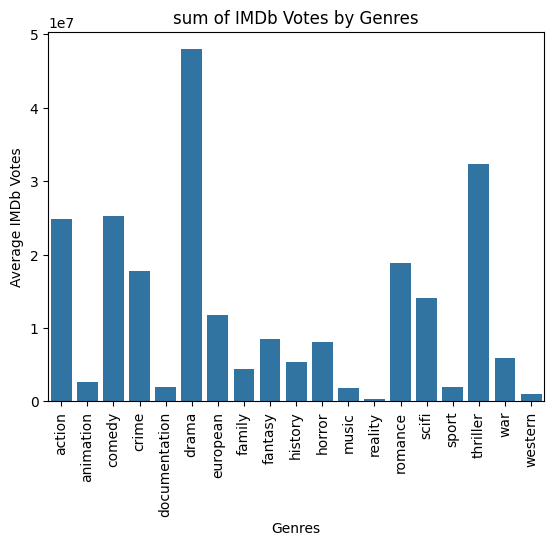

In [ ]:
# applying safe_eval function on genres column
df1['genres']=df1['genres'].apply(safe_eval)
# extracting all the genres using explode method
df_exp=df1.explode('genres')
#dropping all the null values from the imdb_votes column and group by data on the basis of genres
df_genre=df_exp.dropna(subset=['imdb_votes']).groupby('genres')['imdb_votes'].sum().reset_index()
#plotting the bar graph
sns.barplot(data=df_genre, x='genres', y='imdb_votes')
plt.xticks(rotation=90)
plt.xlabel('Genres')
plt.ylabel('Average IMDb Votes')
plt.title('sum of IMDb Votes by Genres')
plt.show()

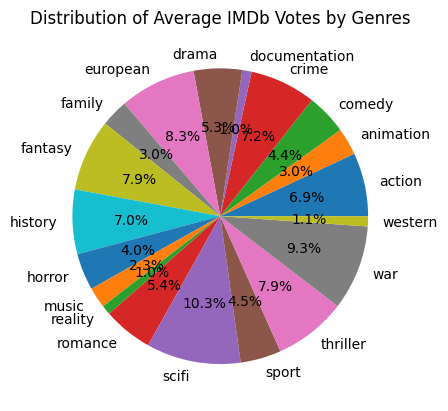

In [ ]:
# plotting the pie chart to get the better perspective
plt.pie(df_genre['imdb_votes'], labels=df_genre['genres'], autopct='%0.1f%%')
plt.title('Distribution of Average IMDb Votes by Genres')
plt.show()

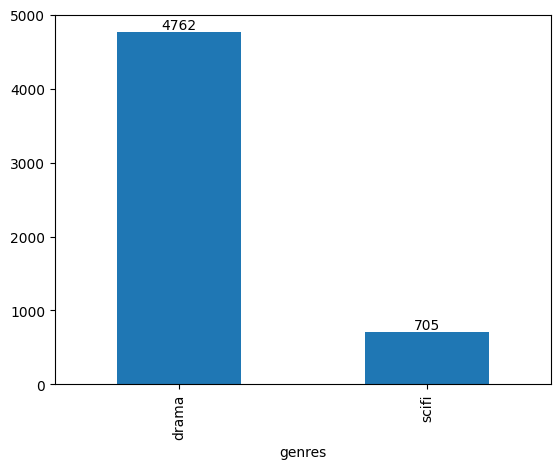

In [ ]:
ax=df_exp[(df_exp['genres'].isin(['drama', 'scifi']))]
bx=ax['genres'].value_counts().plot(kind='bar')
for container in bx.containers:
    bx.bar_label(container)



<Axes: ylabel='Density'>

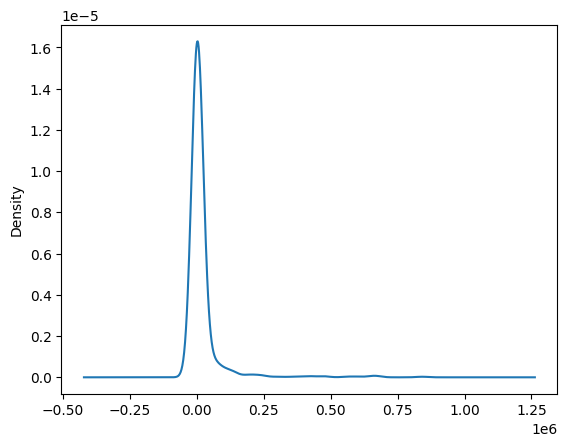

In [ ]:
ax=df_exp[(df_exp['genres'].isin(['scifi']))]
ax['imdb_votes'].plot(kind='kde')

<Axes: ylabel='Density'>

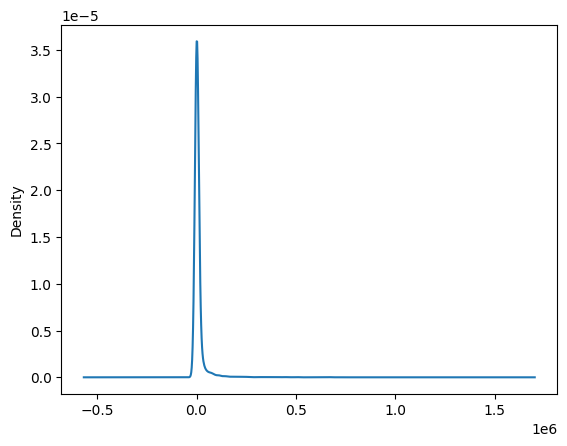

In [ ]:
ax=df_exp[(df_exp['genres'].isin(['drama']))]
ax['imdb_votes'].plot(kind='kde')

### Considering the Parameter in which content got **Above Average IMDb Score** and **Above Average Votes**

**Conclusion**
- Now Genres like **Drama**, **Thriller**, **Comedy** and **Action** comes into the picture.
- **Sci-fi** and **War** has little share. This indicates that both the genre may be **popular but inconsistent in quality**.
- Countries like **GB** and **IN** contributing significantlly on both the parameter after the **US**.

In [ ]:
# using function safe_eval on Genres column
df1['genres']=df1['genres'].apply(safe_eval)
df_exp=df1.explode('genres')
df_exp['production_countries']=df_exp['production_countries'].apply(safe_eval)
df_exp1=df_exp.explode('production_countries')
# using the filter for above avg imdb votes and imdb score
ax=df_exp1[(df_exp1['imdb_votes']>df_exp1['imdb_votes'].mean())&
 (df_exp1['imdb_score']>df_exp1['imdb_score'].mean())]
genre_country=(ax.groupby(['genres', 'production_countries']).size()
.reset_index(name='count'))
#Plotting stacked bar graph
fig = px.bar(genre_country, x='genres', y='count', color='production_countries',
            title='Gneres by Countries(Above Avg IMDb votes & IMDb Score)')
fig.update_layout(barmode='stack', xaxis_tickangle=-45)
fig.show()


In [ ]:
#plotting the pie chart to get the better view of genres shares'
genres_count=ax['genres'].value_counts().reset_index()
genres_count.columns=['genres', 'count']
fig=px.pie(genres_count, values='count', names='genres', title='Genres Share')
fig.show()

###Top 5 Title which performed well on **AvgIMDb score & Avg IMDb** **votes**

Text(0.5, 1.0, 'Top 10 Movies with Above Average Ratings')

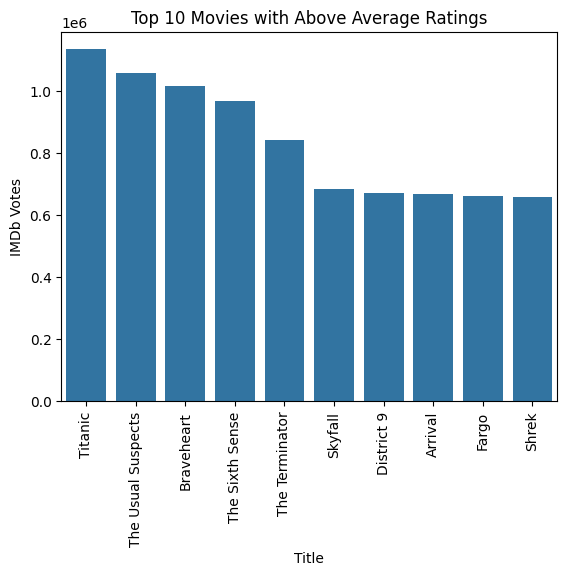

In [ ]:
#dropping the null values from both the columns
df_clean=df1.dropna(subset=['imdb_score', 'imdb_votes'])
#applying the filter for movie and above average ratings
df_title=df_clean[(df_clean['type']=='MOVIE')&(df_clean['imdb_score']>=df_clean['imdb_score'].mean())&
 (df_clean['imdb_votes']>=df_clean['imdb_votes'].mean())]
#sorting the data based on votes
df_sort=df_title.sort_values(by='imdb_votes', ascending=False).head(10)
#plotting the graph with the help of seaborn
sns.barplot(data=df_sort, x='title', y='imdb_votes')
plt.xlabel('Title')
plt.ylabel('IMDb Votes')
plt.xticks(rotation=90)
plt.title('Top 10 Movies with Above Average Ratings')


Text(0.5, 1.0, 'Top 10 Shows with Above Average Ratings')

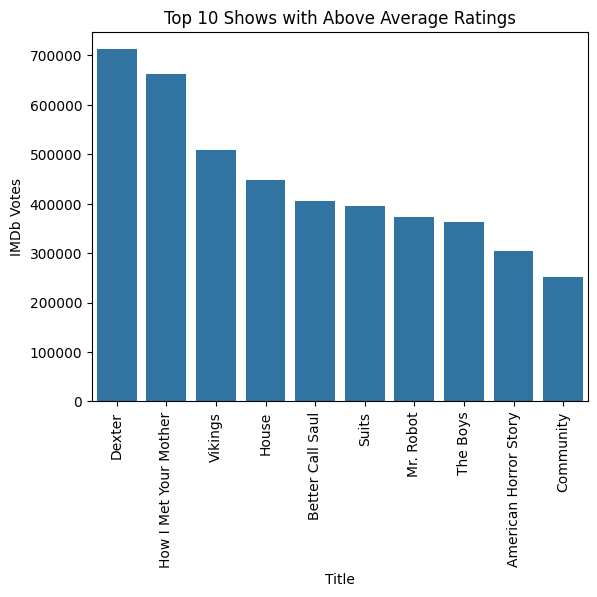

In [ ]:
#dropping the null values from both the columns
df_clean=df1.dropna(subset=['imdb_score', 'imdb_votes'])
#applying the filter for SHOW and above average ratings
df_title=df_clean[(df_clean['type']=='SHOW')&(df_clean['imdb_score']>=df_clean['imdb_score'].mean())&
 (df_clean['imdb_votes']>=df_clean['imdb_votes'].mean())]
#sorting the data based on votes
df_sort=df_title.sort_values(by='imdb_votes', ascending=False).head(10)
#plotting the graph with the help of seaborn
sns.barplot(data=df_sort, x='title', y='imdb_votes')
plt.xlabel('Title')
plt.ylabel('IMDb Votes')
plt.xticks(rotation=90)
plt.title('Top 10 Shows with Above Average Ratings')

###IMDb Score vs IMDb Votes vs Production Countries

**Conclusion**
- Higher production volume does not necessarily translate into higher quality output.
- While **US** leads in total movie production, countries like **GB** show a comparatively higher proportion of above-average movies.

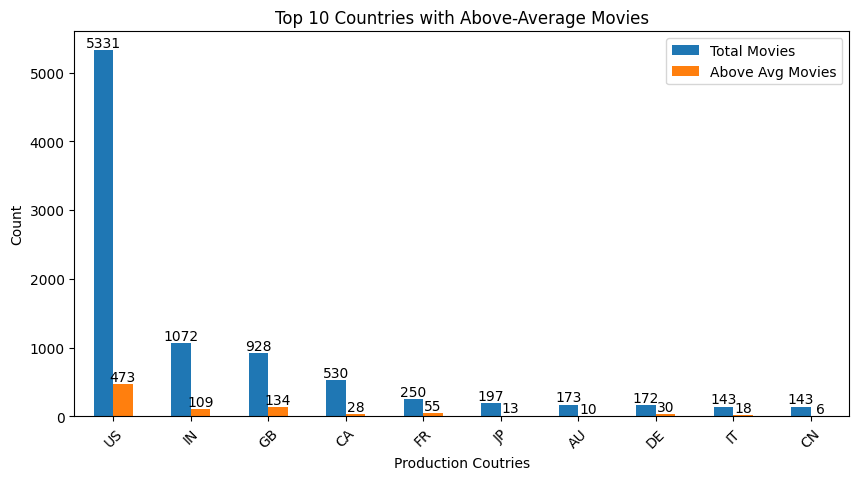

In [ ]:
# converting string list to actual list of countries by applying function safe_eval
df1['production_countries']=df1['production_countries'].apply(safe_eval)
# explode countries
df_exp=df1.explode('production_countries')
# total movies and shows per country
total_counts=df_exp['production_countries'].value_counts()
# filtering above average movies on the basis of imdb score and imdb votes
above_avg=df_exp[(df_exp['imdb_score']>df_exp['imdb_score'].mean())
&(df_exp['imdb_votes']>df_exp['imdb_votes'].mean())]
above_counts=above_avg['production_countries'].value_counts()
# combining both the dataframe(total counts and above average counts)
combined=pd.DataFrame({'Total Movies':total_counts, 'Above Avg Movies':above_counts}).fillna(0)
combined=combined.sort_values(by='Total Movies', ascending=False).head(10)
# plotting the graph
ax=combined.plot(kind='bar', figsize=(10,5))
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Top 10 Countries with Above-Average Movies')
ax.set_xlabel('Production Coutries')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### IMDb Votes vs Runtime

**Conclusion**
- There is **no** strong relationship between **runtime** and **IMDb** votes.
- Mild Positive relationship till ~110 min.
- Popular movies exist across a wide range of runtimes.
- After seeing this we can conclude that Runtime alone does not influence audience engagement.

In [ ]:
# checking the null values
df1[['imdb_score', 'imdb_votes']].isnull().sum()

,0
imdb_score,1021
imdb_votes,1031


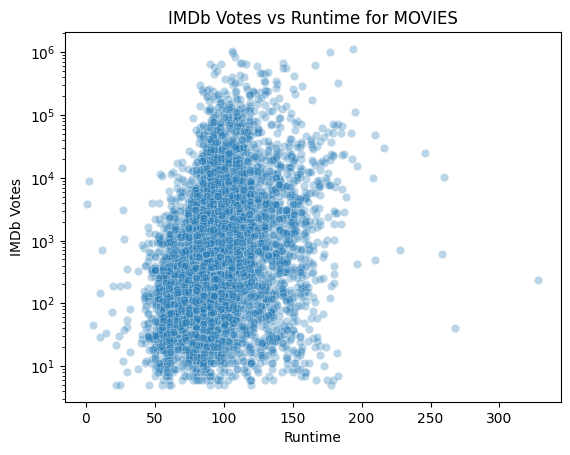

In [ ]:
#dropping the null values from both the columns
df2=df1.dropna(subset=['imdb_votes', 'runtime'])
# using filter for movies
df2=df2[df2['type']=='MOVIE']
# plotting the graph
sns.scatterplot(data=df2, x='runtime', y='imdb_votes', alpha=0.3)
plt.xlabel('Runtime')
plt.ylabel('IMDb Votes')
plt.yscale('log')
plt.title('IMDb Votes vs Runtime for MOVIES')
plt.show()

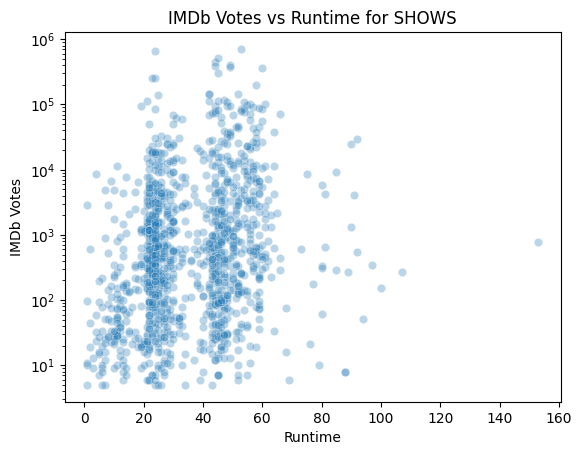

In [ ]:
# dropping the null values from the columns
df2=df1.dropna(subset=['imdb_votes', 'runtime'])
# using filter for show
df2=df2[df2['type']=='SHOW']
# Plotting the graph
sns.scatterplot(data=df2, x='runtime', y='imdb_votes', alpha=0.3)
plt.xlabel('Runtime')
plt.ylabel('IMDb Votes')
plt.yscale('log')
plt.title('IMDb Votes vs Runtime for SHOWS')
plt.show()

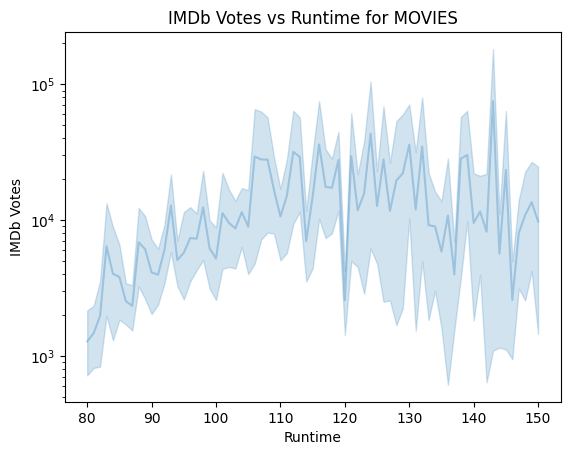

In [ ]:
# dropping the null values from the columns
df2=df1.dropna(subset=['imdb_votes', 'runtime'])
ax=df2[(df2['runtime']>=80) & (df2['runtime']<=150)]
ax=ax[ax['type']=='MOVIE']
# using the graph
sns.lineplot(data=ax, x='runtime', y='imdb_votes', alpha=0.3)
plt.xlabel('Runtime')
plt.ylabel('IMDb Votes')
plt.yscale('log')
plt.title('IMDb Votes vs Runtime for MOVIES')
plt.show()


### IMDb Score vs Runtime

**Conclusion**
- Both movies and shows show little to no correlation between runtime and IMDb
score, indicating that content quality is not driven by duration. **Shows** tend to
recieve more consistent and slightly higher ratings compared to movies.

In [ ]:
df1[['imdb_score','runtime']].isnull().sum()

,0
imdb_score,1021
runtime,0


Text(0.5, 1.0, 'IMDb Score vs Runtime for MOVIES')

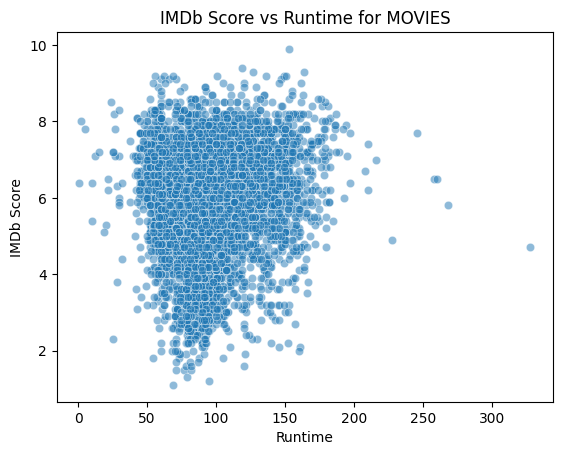

In [ ]:
df2=df1.dropna(subset=['imdb_score', 'runtime'])
# using filter for Movies
df_movie=df2[df2['type']=='MOVIE']
sns.scatterplot(data=df_movie, x='runtime', y='imdb_score', alpha=0.5)
plt.xlabel('Runtime')
plt.ylabel('IMDb Score')
plt.title('IMDb Score vs Runtime for MOVIES')

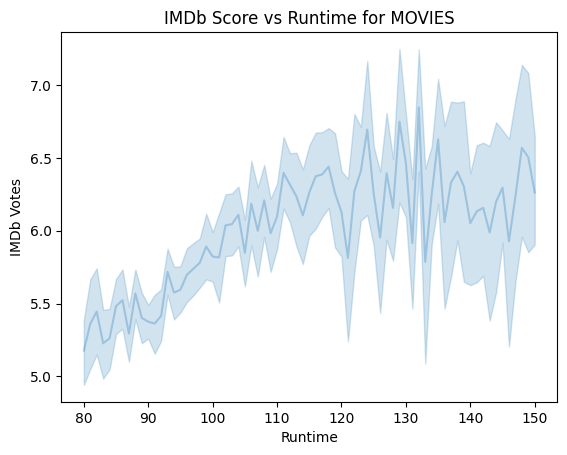

In [ ]:
#dropping the null values
df2=df1.dropna(subset=['imdb_score', 'runtime'])
# using the filter runtime between 80 to 120
ax=df2[(df2['runtime']>=80) & (df2['runtime']<=150)]
#using the filter for movies
ax=ax[ax['type']=='MOVIE']
# plotting the line graph
sns.lineplot(data=ax, x='runtime', y='imdb_score', alpha=0.3)
plt.xlabel('Runtime')
plt.ylabel('IMDb Votes')
plt.title('IMDb Score vs Runtime for MOVIES')
plt.show()

Text(0.5, 1.0, 'IMDb Score vs Runtime for SHOWS')

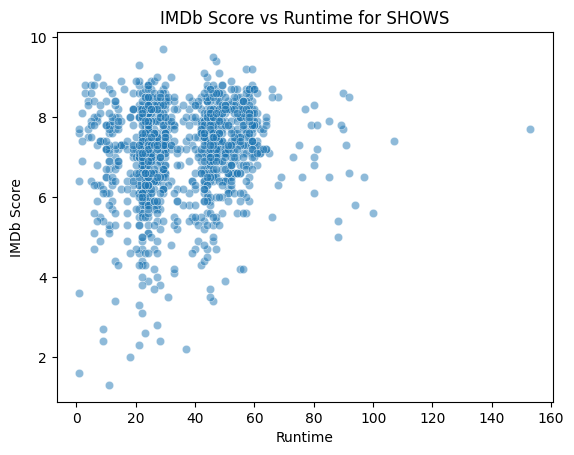

In [ ]:
# using filter for shows
df_show=df1[df1['type']=='SHOW']
#plotting the graph
sns.scatterplot(data=df_show, x='runtime', y='imdb_score', alpha=0.5)
plt.xlabel('Runtime')
plt.ylabel('IMDb Score')
plt.title('IMDb Score vs Runtime for SHOWS')

### IMDb Score vs TMDb Popularity

**Conclusion**
- Very Weak correlation.
- Highly popular titles do not necessarily have higher ratings.
- Majority of titles cluster between IMDb scores 5-7.5


In [ ]:
# checking the correlation
df1['imdb_score'].corr(df1['tmdb_popularity'])

np.float64(0.07156066181794238)

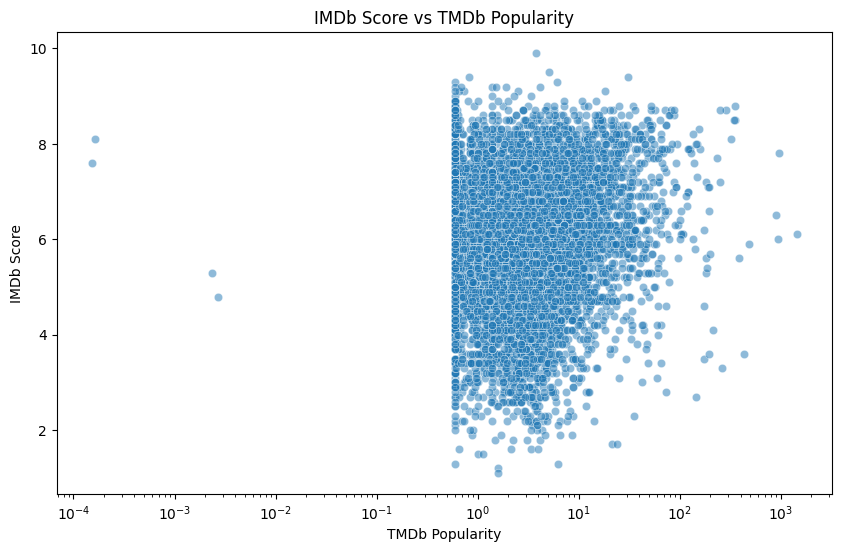

In [ ]:
# dropping the null values
df_clean=df1.dropna(subset=['imdb_score', 'tmdb_popularity'])
#plotting the graph
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='tmdb_popularity', y='imdb_score', alpha=0.5)
plt.xlabel('TMDb Popularity')
plt.ylabel('IMDb Score')
plt.title('IMDb Score vs TMDb Popularity')
plt.xscale('log')

In [ ]:
# checking the total content which have less than 1 popularity
(df1['tmdb_popularity']<1).sum()

np.int64(1843)

In [ ]:
df1[df1['tmdb_popularity']<1][['tmdb_popularity', 'imdb_score']]

,tmdb_popularity,imdb_score
79,0.600,NaN
84,0.600,5.9
92,0.747,4.9
130,0.600,5.7
131,0.963,6.1
...,...,...
9861,0.600,NaN
9862,0.945,8.4
9864,0.954,4.0
9867,0.600,NaN


### Pair plot
(IMDb score, IMDb Votes, TMDb Popularity, TMDb Score)

**Conclusion**
- Moderate positive correlation between imdb score and tmdb score.
- Most points are concentrated between 4-7. That means majority of the content
is average rated.
- Higher imdb score doest not mean more popularity.
- A very weak positive correlation appears between imdb score and imdb votes. Higher imdb votes do not guarantee higher imdb score.

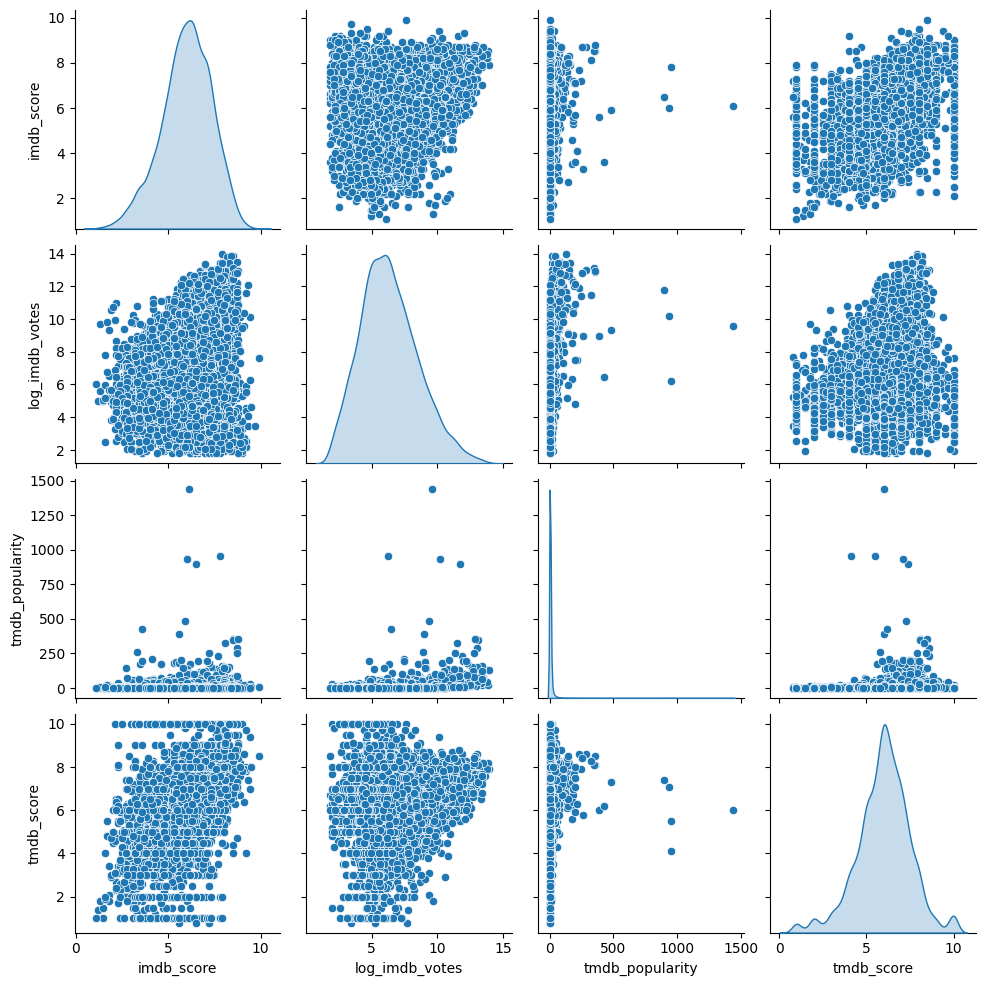

In [ ]:
#using logscale on votes to get proportional spacing since it has huge variation
df1['log_imdb_votes']=np.log1p(df1['imdb_votes'])
#selecting columns
cols=['imdb_score', 'log_imdb_votes', 'tmdb_popularity', 'tmdb_score']
#plotting the graph
sns.pairplot(df1[cols], diag_kind='kde')
plt.show()

In [ ]:
# checking the correlation between imdb score and imdb votes
df1['imdb_score'].corr(df1['imdb_votes'])

np.float64(0.1658793468922927)

In [ ]:
# checking the correlation between imdb votes and tmdb score
df1['imdb_votes'].corr(df1['tmdb_score'])

np.float64(0.14678595934818398)

### HEATMAP
(Runtime, IMDb Score, IMDb Votes, TMDb Popularity)

**Conclusion**
- No strong correlation in dataset
- Popularity related variables (votes and tmdb popularity) ae somewhat related.
- IMDb score is not strongly related to runtime or popularity.


<Axes: >

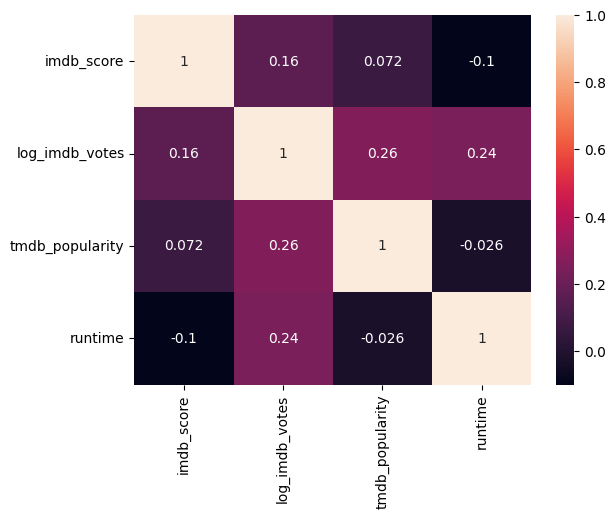

In [ ]:
#using logscale
df1['log_imdb_votes']=np.log1p(df1['imdb_votes'])
#selecting the columns
cols=['imdb_score', 'log_imdb_votes', 'tmdb_popularity', 'runtime']
#plotting the graph
sns.heatmap(df1[cols].corr(), annot=True)

HEATMAP for(Release Year, IMDb Score, IMDb Votes, TMDb Popularity)

<Axes: >

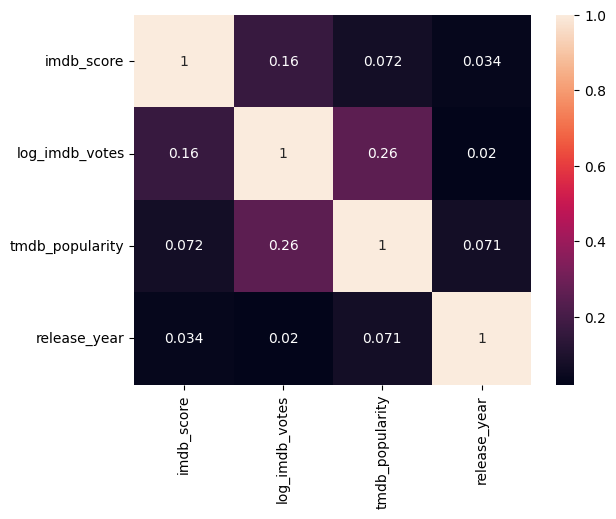

In [ ]:
#using logscale
df1['log_imdb_votes']=np.log1p(df1['imdb_votes'])
#selecting columns
cols=['imdb_score', 'log_imdb_votes', 'tmdb_popularity', 'release_year']
#plotting the graph
sns.heatmap(df1[cols].corr(), annot=True)

###**Analysing CREDITS Dataset**

**Conclusion**
- CREDITS dataset has 124235 rows and 5 columns.


In [ ]:
#dataset first look
df

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


In [ ]:
#checking for total duplicated values
df.duplicated().sum()

np.int64(56)

In [ ]:
# looking into the duplicated values
df[df.duplicated(keep=False)]

,person_id,id,name,character,role
9132,130904,tm89134,Buck Jones,Buck Roberts,ACTOR
9133,36589,tm89134,Tim McCoy,Marshal McCall,ACTOR
9134,130905,tm89134,Raymond Hatton,Sandy,ACTOR
9135,132916,tm89134,Christine McIntyre,Alice Borden,ACTOR
9136,132381,tm89134,Dave O'Brien,Joe Martin,ACTOR
...,...,...,...,...,...
13033,576342,tm137955,Clarence Geldart,Dr. Fleming,ACTOR
13034,60957,tm137955,Edward LeSaint,Judge Harvey E. Blake,ACTOR
13035,576620,tm137955,Finis Barton,Gladys,ACTOR
13036,137455,tm137955,Sam Flint,Dr. Greenwood,ACTOR


In [ ]:
df[df['name']=='Buck Jones']

,person_id,id,name,character,role
9132,130904,tm89134,Buck Jones,Buck Roberts,ACTOR
9156,130904,tm89134,Buck Jones,Buck Roberts,ACTOR
9307,130904,tm210833,Buck Jones,Marshal Buck Roberts,ACTOR
10750,130904,tm79594,Buck Jones,U. S. Marshal Buck Roberts,ACTOR
16011,130904,tm85160,Buck Jones,Marshal Buck Roberts,ACTOR
22427,130904,tm32643,Buck Jones,Himself,ACTOR


In [ ]:
df[df.duplicated(subset=['person_id', 'id'], keep=False)]

,person_id,id,name,character,role
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
26,21174,tm19248,Buster Keaton,NaN,DIRECTOR
462,15246,tm88001,Orson Welles,Charles Rankin,ACTOR
477,15246,tm88001,Orson Welles,NaN,DIRECTOR
642,21174,tm3541,Buster Keaton,William 'Willie' Canfield Jr.,ACTOR
...,...,...,...,...,...
124211,2088979,tm1078263,Nikki H. Royal,NaN,DIRECTOR
124221,2084915,tm1079144,Jay Nog,Self,ACTOR
124222,2084915,tm1079144,Jay Nog,NaN,DIRECTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


In [ ]:
df[df.duplicated(subset=['person_id', 'id', 'role'], keep=False)]

,person_id,id,name,character,role
1704,61125,tm77319,Jack Deery,Party Guest (uncredited),ACTOR
1705,61125,tm77319,Jack Deery,Preacher at Wedding (uncredited),ACTOR
1853,58703,tm4525,Thomas Browne Henry,Dunning,ACTOR
1872,58703,tm4525,Thomas Browne Henry,Dunning (uncredited),ACTOR
4412,21174,tm73200,Buster Keaton,Lonesome Polecat,ACTOR
...,...,...,...,...,...
121558,30072,tm1031525,Nancy Kerrigan,Helen Hen,ACTOR
121943,228580,tm1103576,Shine Tom Chacko,A stag hunter,ACTOR
121944,68296,tm1103576,Sunil Sukhada,Percussionist,ACTOR
121951,68296,tm1103576,Sunil Sukhada,Music Store owner,ACTOR


In [ ]:
#dropping the duplicates after thoroughly checking the duplicates
df=df.drop_duplicates(subset=['person_id', 'id', 'role'])

In [ ]:
df.duplicated(subset=['person_id', 'id', 'role']).sum()

np.int64(0)

**Column Types**
- **Categorical Columns**- Name(nominal), Character(nominal), Role(ordinal)
- **Mixed** - Persons ID, ID

**Analysis of Columns**

### Name


**Conlusion**
- There **79758** names in the column.
- **George 'Gabby' Hayes** appeared most number of time **(49)**.

In [ ]:
#checking how many names are there in the dataset
df['name'].value_counts().sort_values(ascending=False)

,count
name,
George 'Gabby' Hayes,49
Roy Rogers,45
Bess Flowers,44
Joseph Kane,41
Gene Autry,40
...,...
Justin Buford,1
Andrew Rubin,1
Michael Hershewe,1


In [ ]:
#checking if there is any null value present in the column
df['name'].isnull().sum()

np.int64(0)

### Role

**Conclusion**
- **115617 roles** are related to actor
-  names of 8386 directors are also present.

In [ ]:
#checking how types of role are there in the datset
df['role'].value_counts()

,count
role,
ACTOR,115617
DIRECTOR,8386


<Axes: xlabel='role'>

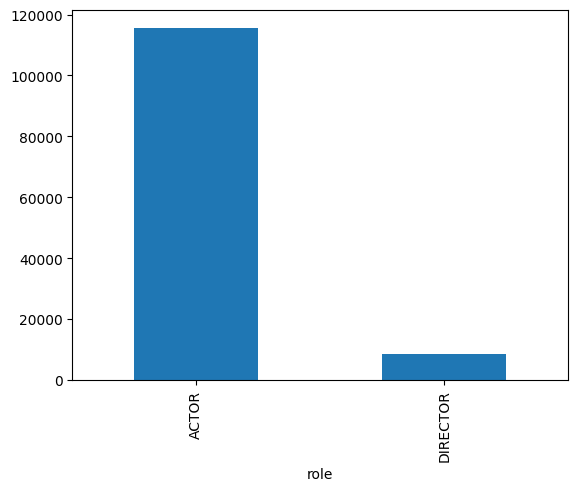

In [ ]:
#visualising the actor and director count to get the better understanding
df['role'].value_counts().plot(kind='bar')

In [ ]:
#checking if there are any null value in the column
df['role'].isnull().sum()

np.int64(0)

### Persons ID

**Conclusion**
- The id column contains unique identifiers for each person.

In [ ]:
#checking how many unique ids persent in the column
df['person_id'].value_counts()

,count
person_id,
100231,49
123795,45
14166,44
151608,41
108842,40
...,...
5993,1
62244,1
98243,1


In [ ]:
#checking if there are any null value in the column
df['person_id'].isnull().sum()

np.int64(0)

### ID

**Conclusion**
- The id column contains unique identifiers for each record.


In [ ]:
#checking how unique id are there in the dataset
df['id'].value_counts()

,count
id,
tm458582,137
tm33144,135
tm244162,135
tm32643,133
tm67583,128
...,...
tm242259,1
ts96003,1
ts16832,1


In [ ]:
#checking if there is any null value is there in the dataset
df['id'].isnull().sum()

np.int64(0)

### **Merging Title Dataset with Credits dataset for better understanding**

In [ ]:
#checking how unique ids are there in the titles dataset
df1['id'].nunique()


9868

In [ ]:
#checking how unique ids are there in the credit dataset
df['id'].nunique()

8861

In [ ]:
#merging both the dataset on common column 'id' using left join
merged_df = pd.merge(df1, df, on='id', how='left')
merged_df

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[comedy, family, animation, action, fantasy, h...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[comedy, family, animation, action, fantasy, h...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[comedy, family, animation, action, fantasy, h...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"[action, drama, war, western, comedy, european]",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"[action, drama, war, western, comedy, european]",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125237,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"[family, drama]",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938565.0,Vijay Thakur,Sanjay Thakur,ACTOR
125238,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"[family, drama]",[],NaN,tt14331982,8.4,49.0,0.645,NaN,728899.0,Vanya Wellens,Budhiya,ACTOR
125239,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"[family, drama]",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620.0,Vishwa Bhanu,Gissu,ACTOR
125240,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"[family, drama]",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620.0,Vishwa Bhanu,NaN,DIRECTOR


In [ ]:
#taking a look into the role column after joining the dataset
merged_df['role'].value_counts()

,count
role,
ACTOR,115617
DIRECTOR,8386


In [ ]:
merged_df['imdb_votes'].describe()

,imdb_votes
count,1.188450e+05
mean,2.313376e+04
std,8.820258e+04
min,5.000000e+00
25%,2.810000e+02
50%,1.228000e+03
75%,7.041000e+03
max,1.133692e+06


In [ ]:
merged_df['imdb_score'].describe()

,imdb_score
count,118875.000000
mean,5.971219
std,1.244435
min,1.100000
25%,5.200000
50%,6.100000
75%,6.800000
max,9.900000


In [ ]:
merged_df['imdb_votes'].isnull().sum()

np.int64(6397)

### Bivariate and Multivariate Analysis on Merged Dataset

###**Best Performing Actors & Directors**

**Conclusion**
- No single actor or director overwhelmingly dominates
- the distribution is not extrememly skewed- counts are somewhat close.  

Text(0.5, 1.0, 'Top 10 Movie Actors with Above Average Content')

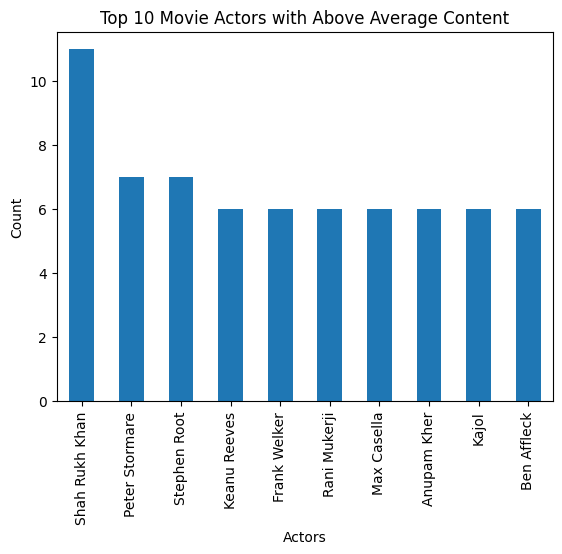

In [ ]:
#applying filter on merged dataset for above avg score and votes for movies
ex=merged_df[(merged_df['imdb_score']>=5.9) & (merged_df['imdb_votes']>=2.313376e+04)
 & (merged_df['role']=='ACTOR')&
 (merged_df['type']=='MOVIE')]
#plotting the graph for top 10
ex['name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Actors')
plt.ylabel('Count')
plt.title('Top 10 Movie Actors with Above Average Content')

Text(0.5, 1.0, 'Top 10 Movie Directors with Above Average Content')

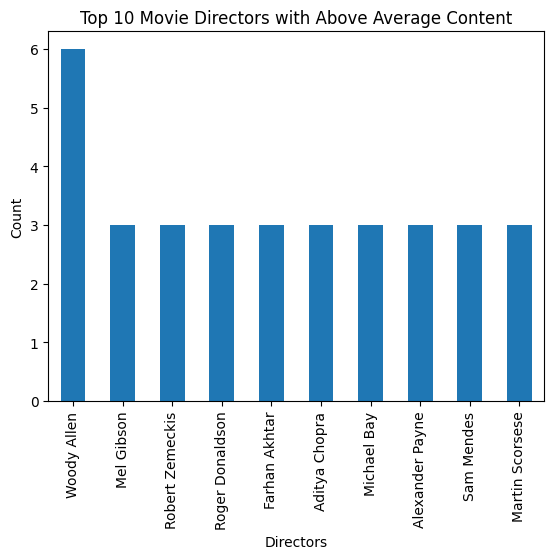

In [ ]:
#applying the filter for movie director for above avg score and votes
ex=merged_df[(merged_df['imdb_score']>=5.9) & (merged_df['imdb_votes']>=2.313376e+04)
 & (merged_df['role']=='DIRECTOR')&
 (merged_df['type']=='MOVIE')]
#plotting the graph with the help of matplotlib
ex['name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Directors')
plt.ylabel('Count')
plt.title('Top 10 Movie Directors with Above Average Content')

Text(0.5, 1.0, 'Top 10 Show Actors with Above Average Content')

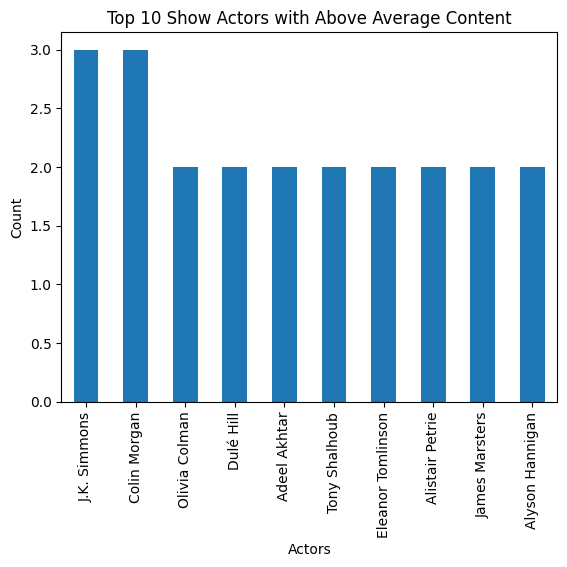

In [ ]:
#applying the filter shows actor for above avg score and votes
ex=merged_df[(merged_df['imdb_score']>=5.9) & (merged_df['imdb_votes']>=2.313376e+04)
 & (merged_df['role']=='ACTOR')&
 (merged_df['type']=='SHOW')]
#plotting the graph with the help of matplotlib
ex['name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Actors')
plt.ylabel('Count')
plt.title('Top 10 Show Actors with Above Average Content')

Text(0.5, 1.0, 'Top 10 Show Directors with Above Average Content')

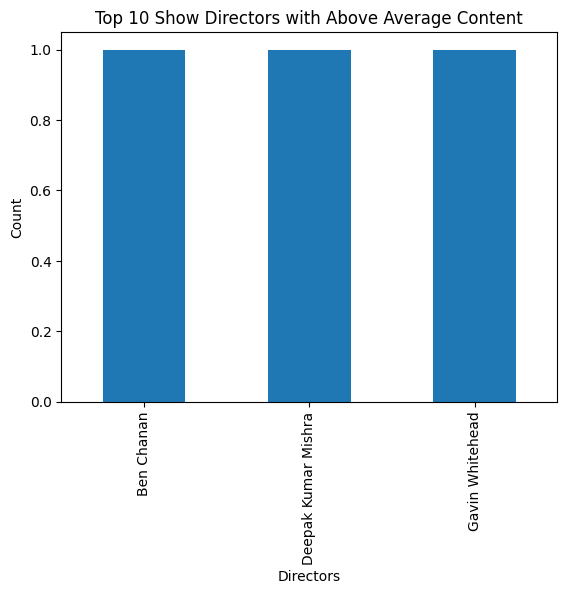

In [ ]:
#applying the filter for shows director for above avg score and votes
ex=merged_df[(merged_df['imdb_score']>=5.9) & (merged_df['imdb_votes']>=2.313376e+04)
 & (merged_df['role']=='DIRECTOR')&
 (merged_df['type']=='SHOW')]
#plotting the graph with the help of matplotlib
ex['name'].value_counts().plot(kind='bar')
plt.xlabel('Directors')
plt.ylabel('Count')
plt.title('Top 10 Show Directors with Above Average Content')

Text(0.5, 1.0, 'Top 10 Latest Movie Actor with Above Average Content')

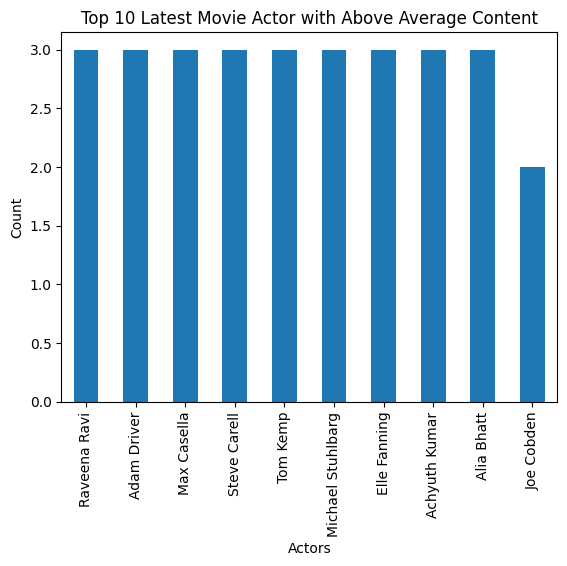

In [ ]:
#applying the filter for movie actor post 2014 movie with above avg score & votes
ex=merged_df[(merged_df['imdb_score']>5.9) & (merged_df['imdb_votes']>2.313376e+04)
 & (merged_df['release_year']>2014)&(merged_df['role']=='ACTOR')&
 (merged_df['type']=='MOVIE')]
#plotting the graph with the help of matplotlib
ex['name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Actors')
plt.ylabel('Count')
plt.title('Top 10 Latest Movie Actor with Above Average Content')

Text(0.5, 1.0, 'Top 10 Latest Show Actor with Above Average Content')

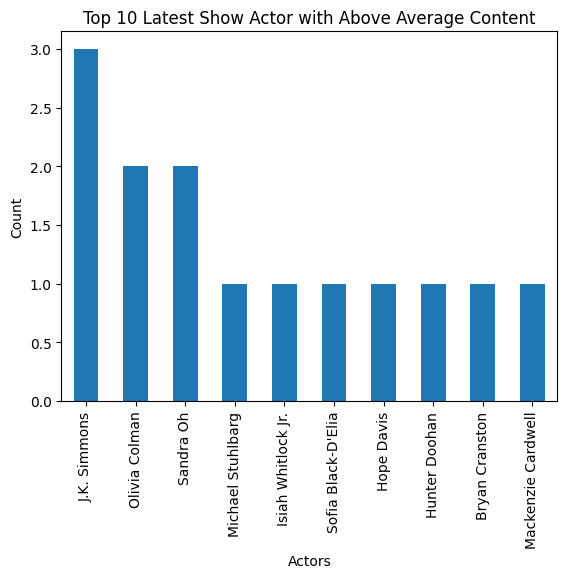

In [ ]:
#applying the filter for show actor post 2014 shows with above avg score & votes
ex=merged_df[(merged_df['imdb_score']>5.9) & (merged_df['imdb_votes']>2.313376e+04)
 & (merged_df['release_year']>2014)&(merged_df['role']=='ACTOR')&
            (merged_df['type']=='SHOW')]
#plotting the graph with the help of matplotlib
ex['name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Actors')
plt.ylabel('Count')
plt.title('Top 10 Latest Show Actor with Above Average Content')

Text(0.5, 1.0, 'Top 10 Latest Directors with Above Average Content')

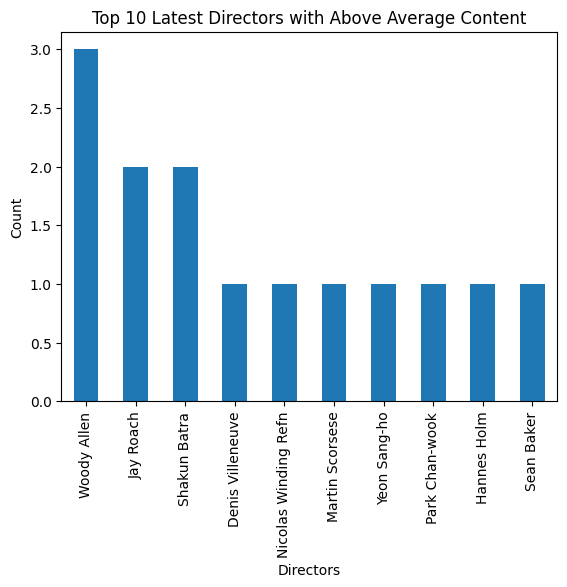

In [ ]:
#applying the filter for director post 2014 shows with above avg score & votes
ex=merged_df[(merged_df['imdb_score']>5.9) & (merged_df['imdb_votes']>2.313376e+04)
 & (merged_df['release_year']>2014)&(merged_df['role']=='DIRECTOR')]
#plotting the graph with the help of matplotlib
ex['name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Directors')
plt.ylabel('Count')
plt.title('Top 10 Latest Directors with Above Average Content')

## **Solution to Business Objective**

**1.** Expand **non-US content acquisition** to diversify the catalog and capture untapped international audience segments.

**2.** Leverage **high-performing pre-2014 titles** to capitalize on nostalgia-driven engagement and proven audience demand.

**3**. Prioritize content with a runtime of **80–120 minutes**, as this duration aligns with higher viewer preference and completion rates.

**4.** Increase investment in **TV shows** to enhance user retention and long-term platform engagement.

**5.** Focus on high-performing genres such as **Drama, Thriller, Comedy, and** **Action** to maximize viewer engagement and platform growth.

**6.** Certain features like Age-Certifications contain insufficient or incomplete data, limiting the reliability of insights and indicating a need for improved data quality and collection processes

# **Conclusion**

The analysis of the Amazon Prime TV Shows and Movies dataset highlights key content trends and strategic opportunities for growth. The platform is dominated by U.S.-based movies, while expanding international content and increasing TV shows could enhance global reach and user retention. Genres such as Drama, Thriller, Comedy, and Action show strong representation, indicating high audience preference. Content with a runtime of 80–120 minutes appears most aligned with viewer consumption patterns. Improving data completeness would further strengthen analytical accuracy and support better content strategy decisions.